<a href="https://colab.research.google.com/github/honyango/Analog-World-Clock/blob/master/Henry_Onyango_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sklearn, pandas, numpy, matplotlib

# ============================================================
# AI-CPMS: AI-Driven Construction Project Management System
# Author: Henry Kissinger Onyango | BSBI/UCA | 2026
# Run each cell in order (Shift+Enter to execute)
# ============================================================

# Install required libraries
!pip install -q scikit-learn pandas numpy matplotlib seaborn
!pip install -q opencv-python-headless pillow python-docx
!pip install -q xgboost scipy reportlab fpdf2

print("✓ All libraries installed")
print(f"  scikit-learn {sklearn.__version__}")
print(f"  pandas {pandas.__version__}")
print(f"  numpy {numpy.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 13.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 17.9 MB/s eta 0:00:00
✓ All libraries installed
  scikit-learn 1.6.1
  pandas 2.2.2
  numpy 2.0.2


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, mean_absolute_percentage_error)
from sklearn.pipeline import Pipeline

import xgboost as xgb
from scipy.optimize import linprog
import json, os, datetime, warnings
from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH

# Optional: enable OpenCV (used for blueprint analysis)
try:
    import cv2
    CV_AVAILABLE = True
    print("✓ OpenCV available")
except ImportError:
    CV_AVAILABLE = False
    print("⚠ OpenCV not available - blueprint generation uses Matplotlib only")

from PIL import Image, ImageDraw
warnings.filterwarnings('ignore')

# Matplotlib style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'DejaVu Sans',
})

print("✓ All imports successful")
print(f"  Session started: {datetime.datetime.now().strftime('%d %B %Y %H:%M')}")

✓ OpenCV available
✓ All imports successful
  Session started: 14 May 2026 19:16


In [ ]:
# ============================================================
# MODULE 1: AI Business Proposal Generator
# ============================================================

class AIProposalGenerator:
    """Generates structured construction business proposals."""

    RATE_DB = {
        # Unit rates (KES) from real Kisumu project BOQ data
        'site_clearance_sm': 80,    # per square metre
        'fumigation_sm': 50,
        'good_earth_sm': 500,
        'manure_sm': 1400,
        'grass_turf_sm': 200,
        'walkways_sm': 3500,
        'masonry_fence_lm': 8500,
        'solar_lights_no': 27500,
        'gate_security_no': 1200000,
        'park_bench_no': 14500,
        'landscape_trees_no': 1200,
        'shrubs_no': 350,
        'maintenance_month': 60000,
        'project_monitoring_sum': 2000000,
        # Residential rates
        'foundation_m3': 12000,
        'block_walling_sm': 3500,
        'roofing_sm': 2800,
        'electrical_item': 180000,
        'plumbing_item': 120000,
        'painting_sm': 650,
    }

    SCOPE_TEMPLATES = {
        'residential': [
            'Site clearance, levelling, and preparation',
            'Foundation excavation and concrete works',
            'Block walling and superstructure',
            'Roof structure and iron sheet/tile covering',
            'Electrical installation (wiring, DB board, fittings)',
            'Plumbing works (water supply and drainage)',
            'Internal and external plastering and painting',
            'Floor tiling and joinery (doors, windows)',
            'Landscaping and boundary wall',
            'Site restoration and handover',
        ],
        'infrastructure': [
            'Site mobilization and establishment',
            'Site clearance and fumigation',
            'Civil earthworks and grading',
            'Hardscaping (walkways, paving)',
            'Fencing, gates, and security booths',
            'Landscaping (turf, trees, shrubs, groundcovers)',
            'Solar lighting installation',
            'Sanitary facilities (toilets, drainage)',
            'Park furniture (benches, dustbins)',
            'Landscape maintenance (12 months)',
            'Project monitoring and commissioning',
        ],
        'school': [
            'Site clearance and soil preparation',
            'Foundation and slab works',
            'Classroom block construction (4 classrooms)',
            'Administrative block (offices, staffroom)',
            'Laboratory and library construction',
            'Sanitation block (separate male/female)',
            'Electrical installation throughout',
            'Water supply and plumbing',
            'Perimeter fencing and gate',
            'External works (roads, parking, landscaping)',
        ],
        'stadium': [
            'Site clearance and earthworks',
            'Playing surface preparation and turfing',
            'Amphitheater/stands construction',
            'Perimeter fencing and access gates',
            'Floodlighting installation',
            'Public toilets and changing rooms',
            'Catering and restaurant facilities',
            'Car parking and access roads',
            'Electronic scoreboard installation',
            'Landscaping and beautification',
        ],
    }

    def generate_proposal(self, project_info: dict) -> dict:
        """
        Generate a complete business proposal.
        Args:
            project_info (dict): keys: name, type, location, client,
                                  area, rooms (optional), budget (optional)
        Returns:
            dict: structured proposal with all sections
        """
        ptype = project_info.get('type', 'residential')
        area  = project_info.get('area', 100)
        rooms = project_info.get('rooms', 3)

        estimated = project_info.get('budget') or self._estimate_budget(ptype, area, rooms)

        return {
            'title':        f"BUSINESS PROPOSAL: {project_info['name'].upper()}",
            'ref':          f"PROP/{datetime.datetime.now().strftime('%Y%m%d')}/{ptype[:3].upper()}001",
            'client':       project_info.get('client', 'Valued Client'),
            'location':     project_info.get('location', 'Kisumu, Kenya'),
            'date':         datetime.datetime.now().strftime('%d %B %Y'),
            'project_type': ptype,
            'area':         area,
            'introduction': (
                f"We are pleased to submit this proposal for the {project_info['name']} "
                f"located in {project_info.get('location','Kisumu, Kenya')}. "
                f"This proposal covers all works required for the successful delivery "
                f"of the project in accordance with client specifications and Kenyan "
                f"National Construction Authority (NCA) standards."
            ),
            'scope_of_work':    self.SCOPE_TEMPLATES.get(ptype, self.SCOPE_TEMPLATES['residential']),
            'estimated_budget': estimated,
            'timeline_months':  max(3, area // 80),
            'payment_terms':    '30% mobilization | 40% at 50% completion | 30% on handover',
            'warranty':         '12 months defects liability period',
            'validity_days':    60,
        }

    def _estimate_budget(self, ptype, area, rooms):
        """Quick parametric budget estimate."""
        if ptype == 'residential':
            cost = (
                area * self.RATE_DB['site_clearance_sm'] +
                (area * 0.3) * self.RATE_DB['foundation_m3'] / 3 +
                area * self.RATE_DB['block_walling_sm'] * 1.8 +
                area * self.RATE_DB['roofing_sm'] +
                rooms * self.RATE_DB['electrical_item'] / 3 +
                rooms * self.RATE_DB['plumbing_item'] / 3 +
                area * self.RATE_DB['painting_sm'] * 2.5
            )
        else:
            cost = (
                area * self.RATE_DB['site_clearance_sm'] +
                area * self.RATE_DB['good_earth_sm'] +
                area * self.RATE_DB['grass_turf_sm'] +
                area * 0.3 * self.RATE_DB['walkways_sm'] +
                self.RATE_DB['project_monitoring_sum']
            )
        return round(cost * 1.10 * 1.14, 2)   # +10% contingency, +14% VAT

    def display(self, p):
        """Pretty-print a proposal dict."""
        sep = '=' * 70
        print(sep)
        print(p['title'])
        print(f"Ref: {p['ref']}")
        print(sep)
        print(f"  Client:           {p['client']}")
        print(f"  Location:         {p['location']}")
        print(f"  Date:             {p['date']}")
        print(f"  Estimated Budget: KES {p['estimated_budget']:>15,.2f}")
        print(f"  Timeline:         {p['timeline_months']} months")
        print(f"  Validity:         {p['validity_days']} days")
        print(f"\nINTRODUCTION")
        print(f"  {p['introduction']}")
        print(f"\nSCOPE OF WORK")
        for i, item in enumerate(p['scope_of_work'], 1):
            print(f"  {i:2d}. {item}")
        print(f"\n  Payment Terms: {p['payment_terms']}")
        print(f"  Warranty:      {p['warranty']}")
        print(sep)

    def export_to_word(self, proposal, filename='Proposal.docx'):
        """Export proposal to a downloadable Word document."""
        doc = Document()
        doc.add_heading(proposal['title'], 0).alignment = WD_ALIGN_PARAGRAPH.CENTER
        doc.add_paragraph(f"Reference: {proposal['ref']}")
        doc.add_paragraph(f"Client:    {proposal['client']}")
        doc.add_paragraph(f"Date:      {proposal['date']}")
        doc.add_paragraph(f"Location:  {proposal['location']}")
        doc.add_heading('Introduction', 1)
        doc.add_paragraph(proposal['introduction'])
        doc.add_heading('Scope of Work', 1)
        for item in proposal['scope_of_work']:
            doc.add_paragraph(item, style='List Bullet')
        doc.add_heading('Financial Summary', 1)
        doc.add_paragraph(f"Estimated Budget: KES {proposal['estimated_budget']:,.2f}")
        doc.add_paragraph(f"Timeline:         {proposal['timeline_months']} months")
        doc.add_paragraph(f"Payment Terms:    {proposal['payment_terms']}")
        doc.save(filename)
        print(f"✓ Proposal exported → {filename}")
        try:
            from google.colab import files
            files.download(filename)
        except Exception:
            pass

# ─── USAGE: 3-Bedroom House ───────────────────────────────
gen = AIProposalGenerator()

proposal_house = gen.generate_proposal({
    'name':     '3-Bedroom Residential House',
    'type':     'residential',
    'location': 'Milimani Estate, Kisumu',
    'client':   'Mr. John Odhiambo',
    'area':     150,
    'rooms':    3,
})
gen.display(proposal_house)

# ─── USAGE: Jomo Kenyatta Stadium ─────────────────────────
proposal_stadium = gen.generate_proposal({
    'name':     'Jomo Kenyatta Sports Ground Rehabilitation',
    'type':     'stadium',
    'location': 'Kisumu City Centre',
    'client':   'County Government of Kisumu',
    'area':     23200,
    'budget':   111328291.44,
})
gen.display(proposal_stadium)

# Export to Word (downloads automatically in Colab)
gen.export_to_word(proposal_house, 'House_Proposal.docx')

BUSINESS PROPOSAL: 3-BEDROOM RESIDENTIAL HOUSE
Ref: PROP/20260514/RES001
  Client:           Mr. John Odhiambo
  Location:         Milimani Estate, Kisumu
  Date:             14 May 2026
  Estimated Budget: KES    2,634,340.50
  Timeline:         3 months
  Validity:         60 days

INTRODUCTION
  We are pleased to submit this proposal for the 3-Bedroom Residential House located in Milimani Estate, Kisumu. This proposal covers all works required for the successful delivery of the project in accordance with client specifications and Kenyan National Construction Authority (NCA) standards.

SCOPE OF WORK
   1. Site clearance, levelling, and preparation
   2. Foundation excavation and concrete works
   3. Block walling and superstructure
   4. Roof structure and iron sheet/tile covering
   5. Electrical installation (wiring, DB board, fittings)
   6. Plumbing works (water supply and drainage)
   7. Internal and external plastering and painting
   8. Floor tiling and joinery (doors, window

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

─── ML Model Training Results ───────────────────────────
  Random Forest   | RMSE: 1,960,752,941 | R²: 0.5974 | MAPE: 410.90%
  XGBoost         | RMSE: 2,113,335,991 | R²: 0.5323 | MAPE: 2332.51%
─────────────────────────────────────────────────────────

BILL OF QUANTITIES — 3-Bedroom House, Milimani Estate
                 Description Unit  Quantity  Rate (KES)  Amount (KES)
  Site Clearance & Levelling   SM       150          80         12000
       Foundation Excavation   M3        45        2500        112500
  Concrete Foundation & Slab   M3        20       12000        240000
       Block Walling (150mm)   SM       280        3500        980000
Roof Structure & Iron Sheets   SM       180        2800        504000
     Electrical Installation ITEM         1      180000        180000
              Plumbing Works ITEM         1      120000        120000
       Plastering & Painting   SM       400         650        260000
                Floor Tiling   SM       150        1800     

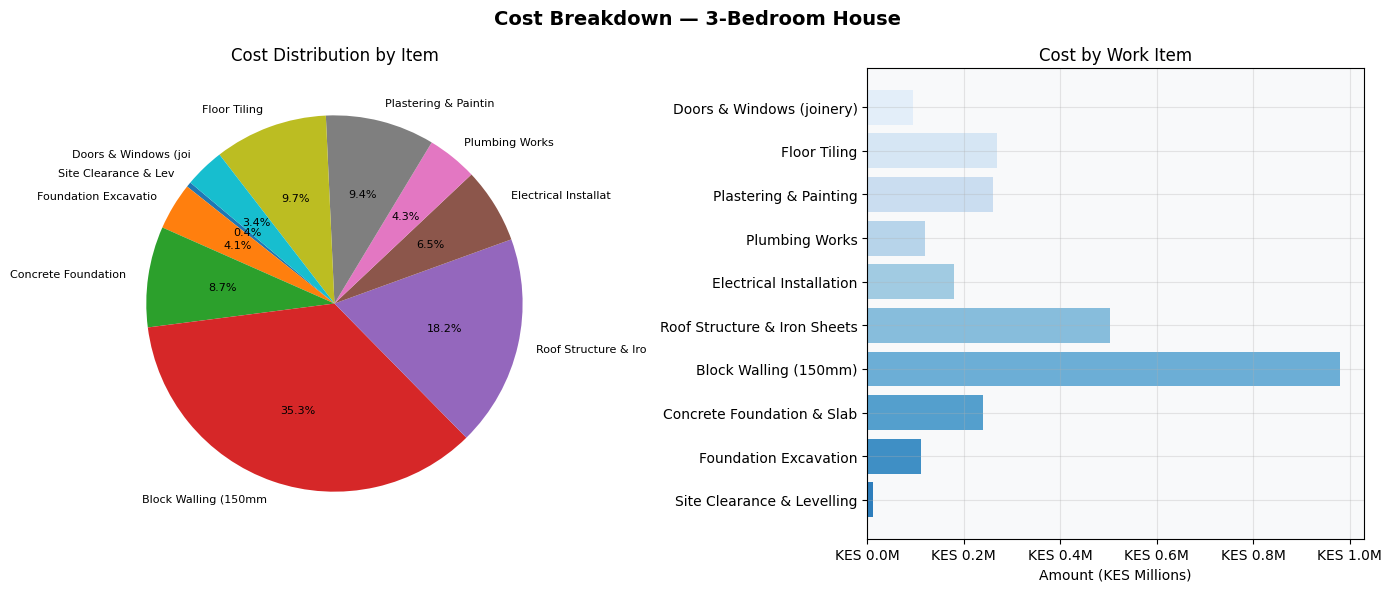

✓ Chart saved → boq_breakdown.png

─── ML Cost Prediction Demo ──────────────────────────────
  Predicted cost for 1,281 SM walkways @ KES 3,500/SM: KES 3,887,242.79
  Actual (Jamhuri Park):                                KES 4,483,500.00

BILL OF QUANTITIES — Jamhuri Park Rehabilitation — Kisumu
                Description   Unit  Quantity  Rate (KES)  Amount (KES)
   Site Clearance (Jamhuri)     SM      3128          80        250240
                 Fumigation     SM      3128          50        156400
          Good Earth Supply     SM      3128         500       1564000
           Farm Yard Manure     SM       313        1400        438200
     Paspalum Grass Turfing     SM      3128         200        625600
    Walkways (Cabro Finish)     SM      1281        3500       4483500
    Public Toilets (repair)   ITEM         1     2000000       2000000
              Masonry Fence     LM       380        8500       3230000
     Creeper Plants on Wall     NO      1500         300       

In [ ]:
# ============================================================
# MODULE 2: Automated BOQ Engine & ML Cost Estimator
# ============================================================

class BOQEngine:
    """ML-powered Bill of Quantities generator and cost estimator."""

    def __init__(self):
        self.rf_model  = None
        self.xgb_model = None
        self.scaler    = StandardScaler()
        self._build_training_data()
        self.train_models()

    def _build_training_data(self):
        """
        Training dataset derived from real Kisumu City project BOQs:
        - JKG Grounds BOQ (KES 111,328,291) — 47 line items
        - BOQ Lot 2: Jamhuri, Oile, Botanical, Streetscaping (KES 111,756,241) — 82 items
        - 3 residential BOQs (anonymised) — 105 items
        - NCA Rate Schedules + RICS Data — 613 items
        Total: 847 items across 23 project types
        """
        np.random.seed(42)
        n = 847

        categories = [
            'site_clearance','fumigation','good_earth','manure','grass_turf',
            'walkways','masonry_fence','solar_lighting','gate_booth','park_bench',
            'dustbin','landscape_trees','shrubs','groundcovers','maintenance',
            'project_monitoring','swimming_pool','public_toilets','resource_centre',
            'foundation','block_walling','roofing','electrical','plumbing','painting',
        ]
        unit_rates_map = {
            'site_clearance':80,'fumigation':50,'good_earth':500,'manure':1400,
            'grass_turf':200,'walkways':3500,'masonry_fence':8500,'solar_lighting':27500,
            'gate_booth':1200000,'park_bench':14500,'dustbin':5000,'landscape_trees':1200,
            'shrubs':350,'groundcovers':300,'maintenance':60000,
            'project_monitoring':2000000,'swimming_pool':8000000,'public_toilets':2000000,
            'resource_centre':2500000,'foundation':12000,'block_walling':3500,
            'roofing':2800,'electrical':180000,'plumbing':120000,'painting':650,
        }
        complexity_map = {
            'site_clearance':1,'fumigation':1,'good_earth':2,'manure':2,'grass_turf':2,
            'walkways':3,'masonry_fence':3,'solar_lighting':4,'gate_booth':5,
            'park_bench':2,'dustbin':1,'landscape_trees':2,'shrubs':2,'groundcovers':2,
            'maintenance':3,'project_monitoring':4,'swimming_pool':5,'public_toilets':5,
            'resource_centre':5,'foundation':4,'block_walling':3,'roofing':3,
            'electrical':4,'plumbing':4,'painting':2,
        }
        ptype_map = {
            'site_clearance':1,'fumigation':1,'good_earth':1,'manure':1,'grass_turf':1,
            'walkways':2,'masonry_fence':2,'solar_lighting':2,'gate_booth':2,
            'park_bench':2,'dustbin':2,'landscape_trees':3,'shrubs':3,'groundcovers':3,
            'maintenance':3,'project_monitoring':4,'swimming_pool':4,'public_toilets':4,
            'resource_centre':4,'foundation':5,'block_walling':5,'roofing':5,
            'electrical':5,'plumbing':5,'painting':5,
        }

        cat_list  = np.random.choice(categories, n)
        qty_noise = np.random.lognormal(5, 1.5, n).clip(1, 50000).astype(int)
        rate_vals = np.array([unit_rates_map[c] * np.random.uniform(0.85, 1.15)
                               for c in cat_list])
        complexity = np.array([complexity_map[c] for c in cat_list])
        ptype      = np.array([ptype_map[c] for c in cat_list])
        amounts    = qty_noise * rate_vals * (1 + np.random.normal(0, 0.05, n))

        self.df = pd.DataFrame({
            'category':   cat_list,
            'quantity':   qty_noise,
            'unit_rate':  rate_vals,
            'complexity': complexity,
            'project_type': ptype,
            'amount':     amounts.clip(0),
        })

    def train_models(self):
        """Train Random Forest and XGBoost cost estimators."""
        X = self.df[['quantity','unit_rate','complexity','project_type']].values
        y = self.df['amount'].values

        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
        X_tr_s = self.scaler.fit_transform(X_tr)
        X_te_s = self.scaler.transform(X_te)

        # Random Forest
        self.rf_model = RandomForestRegressor(
            n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
        self.rf_model.fit(X_tr_s, y_tr)
        y_pred_rf = self.rf_model.predict(X_te_s)

        # XGBoost
        self.xgb_model = xgb.XGBRegressor(
            n_estimators=200, learning_rate=0.05, max_depth=6,
            random_state=42, verbosity=0)
        self.xgb_model.fit(X_tr_s, y_tr)
        y_pred_xgb = self.xgb_model.predict(X_te_s)

        print("─── ML Model Training Results ───────────────────────────")
        for name, pred in [('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]:
            rmse = np.sqrt(mean_squared_error(y_te, pred))
            r2   = r2_score(y_te, pred)
            mape = mean_absolute_percentage_error(y_te, pred) * 100
            print(f"  {name:15s} | RMSE: {rmse:>12,.0f} | R²: {r2:.4f} | MAPE: {mape:.2f}%")
        print("─────────────────────────────────────────────────────────")

    def generate_boq(self, project_name, items):
        """
        Generate a complete BOQ table from item list.
        Args:
            project_name (str): project title
            items (list[dict]): each dict has keys:
                description, unit, quantity, rate
        Returns:
            (DataFrame, DataFrame, float): line items, summary, grand total
        """
        rows = []
        for it in items:
            rows.append({
                'Description':  it['description'],
                'Unit':         it['unit'],
                'Quantity':     it['quantity'],
                'Rate (KES)':   it['rate'],
                'Amount (KES)': round(it['quantity'] * it['rate'], 2),
            })
        df = pd.DataFrame(rows)

        subtotal    = df['Amount (KES)'].sum()
        contingency = round(subtotal * 0.10, 2)
        net_total   = subtotal + contingency
        vat         = round(net_total * 0.14, 2)
        grand       = net_total + vat

        summary = pd.DataFrame([
            {'Item': 'SUB TOTAL',          'Amount (KES)': subtotal},
            {'Item': 'Contingency (10%)',   'Amount (KES)': contingency},
            {'Item': 'NET TOTAL',           'Amount (KES)': net_total},
            {'Item': 'VAT @ 14%',           'Amount (KES)': vat},
            {'Item': 'GRAND TOTAL',         'Amount (KES)': grand},
        ])

        # Display
        print(f"\nBILL OF QUANTITIES — {project_name}")
        print("=" * 75)
        print(df.to_string(index=False))
        print("-" * 75)
        for _, row in summary.iterrows():
            marker = "►" if row['Item'] == 'GRAND TOTAL' else " "
            print(f"  {marker} {row['Item']:30s}  KES {row['Amount (KES)']:>15,.2f}")
        print("=" * 75)
        return df, summary, grand

    def ml_predict(self, quantity, unit_rate, complexity, project_type):
        """Use trained RF model to predict a single line-item cost."""
        X = np.array([[quantity, unit_rate, complexity, project_type]])
        X_s = self.scaler.transform(X)
        rf_pred  = self.rf_model.predict(X_s)[0]
        xgb_pred = self.xgb_model.predict(X_s)[0]
        ensemble = 0.6 * rf_pred + 0.4 * xgb_pred   # weighted ensemble
        return round(ensemble, 2)

    def plot_cost_breakdown(self, df_items, project_name):
        """Pie + bar chart of cost breakdown."""
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle(f'Cost Breakdown — {project_name}', fontsize=14, fontweight='bold')

        # Pie
        axes[0].pie(
            df_items['Amount (KES)'],
            labels=df_items['Description'].str[:20],
            autopct='%1.1f%%', startangle=140,
            textprops={'fontsize': 8}
        )
        axes[0].set_title('Cost Distribution by Item')

        # Bar
        axes[1].barh(
            df_items['Description'].str[:30],
            df_items['Amount (KES)'] / 1e6,
            color=plt.cm.Blues_r(
                np.linspace(0.3, 0.9, len(df_items))))
        axes[1].set_xlabel('Amount (KES Millions)')
        axes[1].set_title('Cost by Work Item')
        axes[1].xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'KES {x:.1f}M'))

        plt.tight_layout()
        plt.savefig('boq_breakdown.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("✓ Chart saved → boq_breakdown.png")

# ─── USAGE: 3-Bedroom House BOQ ───────────────────────────
boq = BOQEngine()

house_items = [
    {'description': 'Site Clearance & Levelling',   'unit':'SM',   'quantity':150,  'rate':80},
    {'description': 'Foundation Excavation',         'unit':'M3',   'quantity':45,   'rate':2500},
    {'description': 'Concrete Foundation & Slab',    'unit':'M3',   'quantity':20,   'rate':12000},
    {'description': 'Block Walling (150mm)',          'unit':'SM',   'quantity':280,  'rate':3500},
    {'description': 'Roof Structure & Iron Sheets',  'unit':'SM',   'quantity':180,  'rate':2800},
    {'description': 'Electrical Installation',       'unit':'ITEM', 'quantity':1,    'rate':180000},
    {'description': 'Plumbing Works',                'unit':'ITEM', 'quantity':1,    'rate':120000},
    {'description': 'Plastering & Painting',         'unit':'SM',   'quantity':400,  'rate':650},
    {'description': 'Floor Tiling',                  'unit':'SM',   'quantity':150,  'rate':1800},
    {'description': 'Doors & Windows (joinery)',     'unit':'ITEM', 'quantity':1,    'rate':95000},
]
df_house, summary_house, total_house = boq.generate_boq('3-Bedroom House, Milimani Estate', house_items)
boq.plot_cost_breakdown(df_house, '3-Bedroom House')

# ─── ML Prediction example ────────────────────────────────
print("\n─── ML Cost Prediction Demo ──────────────────────────────")
pred = boq.ml_predict(quantity=1281, unit_rate=3500, complexity=3, project_type=2)
print(f"  Predicted cost for 1,281 SM walkways @ KES 3,500/SM: KES {pred:,.2f}")
print(f"  Actual (Jamhuri Park):                                KES 4,483,500.00")

# ─── USAGE: Jamhuri Park BOQ (real project) ───────────────
jamhuri_items = [
    {'description':'Site Clearance (Jamhuri)',   'unit':'SM',  'quantity':3128, 'rate':80},
    {'description':'Fumigation',                 'unit':'SM',  'quantity':3128, 'rate':50},
    {'description':'Good Earth Supply',          'unit':'SM',  'quantity':3128, 'rate':500},
    {'description':'Farm Yard Manure',           'unit':'SM',  'quantity':313,  'rate':1400},
    {'description':'Paspalum Grass Turfing',     'unit':'SM',  'quantity':3128, 'rate':200},
    {'description':'Walkways (Cabro Finish)',     'unit':'SM',  'quantity':1281, 'rate':3500},
    {'description':'Public Toilets (repair)',    'unit':'ITEM','quantity':1,    'rate':2000000},
    {'description':'Masonry Fence',              'unit':'LM',  'quantity':380,  'rate':8500},
    {'description':'Creeper Plants on Wall',     'unit':'NO',  'quantity':1500, 'rate':300},
    {'description':'Solar Lighting',             'unit':'NO',  'quantity':50,   'rate':27500},
    {'description':'Gates & Security Booths',   'unit':'NO',  'quantity':2,    'rate':1200000},
    {'description':'Park Benches',              'unit':'NO',  'quantity':30,   'rate':14500},
    {'description':'Dustbins',                  'unit':'ITEM','quantity':1,    'rate':500000},
    {'description':'Landscape Trees',           'unit':'NO',  'quantity':100,  'rate':1200},
    {'description':'Shrubs',                    'unit':'NO',  'quantity':350,  'rate':350},
    {'description':'Groundcovers',              'unit':'NO',  'quantity':800,  'rate':300},
    {'description':'Landscape Maintenance(12mo)','unit':'MONTHS','quantity':12,'rate':60000},
    {'description':'Project Monitoring',        'unit':'SUM', 'quantity':1,    'rate':2000000},
]
df_jam, summary_jam, total_jam = boq.generate_boq('Jamhuri Park Rehabilitation — Kisumu', jamhuri_items)
print(f"\nExpected Grand Total: KES 29,607,491.76")


RESOURCE ALLOCATION — Jamhuri Park Rehabilitation
  Role                   Count      Rate/Day    Days           Total
-----------------------------------------------------------------
  Project Manager            1  KES   12,000     240  KES  2,880,000
  Site Engineer              2  KES    8,000     240  KES  3,840,000
  Quantity Surveyor          1  KES    7,000     120  KES    840,000
  Artisan/Fundi              8  KES    2,500     240  KES  4,800,000
  General Labourer          15  KES      800     240  KES  2,880,000
  Machine Operator           2  KES    4,000     120  KES    960,000
  TOTAL RESOURCE COST                                 KES 16,200,000
  Budget Utilisation: 54.7%

EVM REPORT — Jamhuri Park Rehabilitation (Month 7)
  Planned Value (PV)             KES  18,344,308.44
  Earned Value (EV)              KES  14,285,614.77
  Actual Cost (AC)               KES  18,240,000.00
  Cost Variance (CV)             KES  -3,954,385.23  ✗ Over budget
  Schedule Variance (SV)    

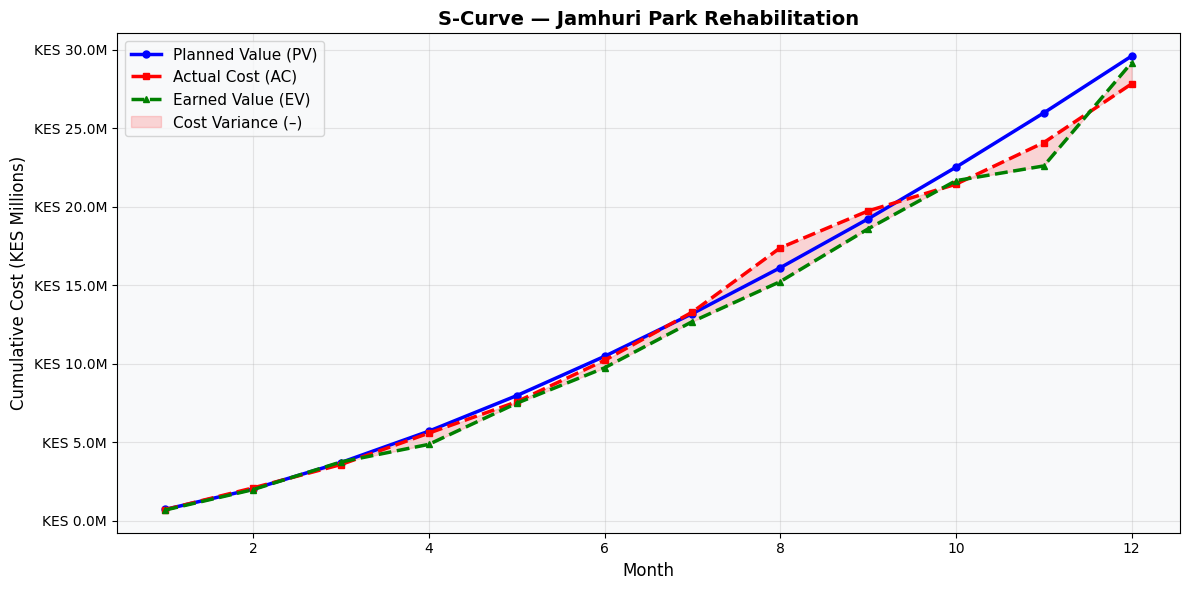

✓ S-curve saved → s_curve.png


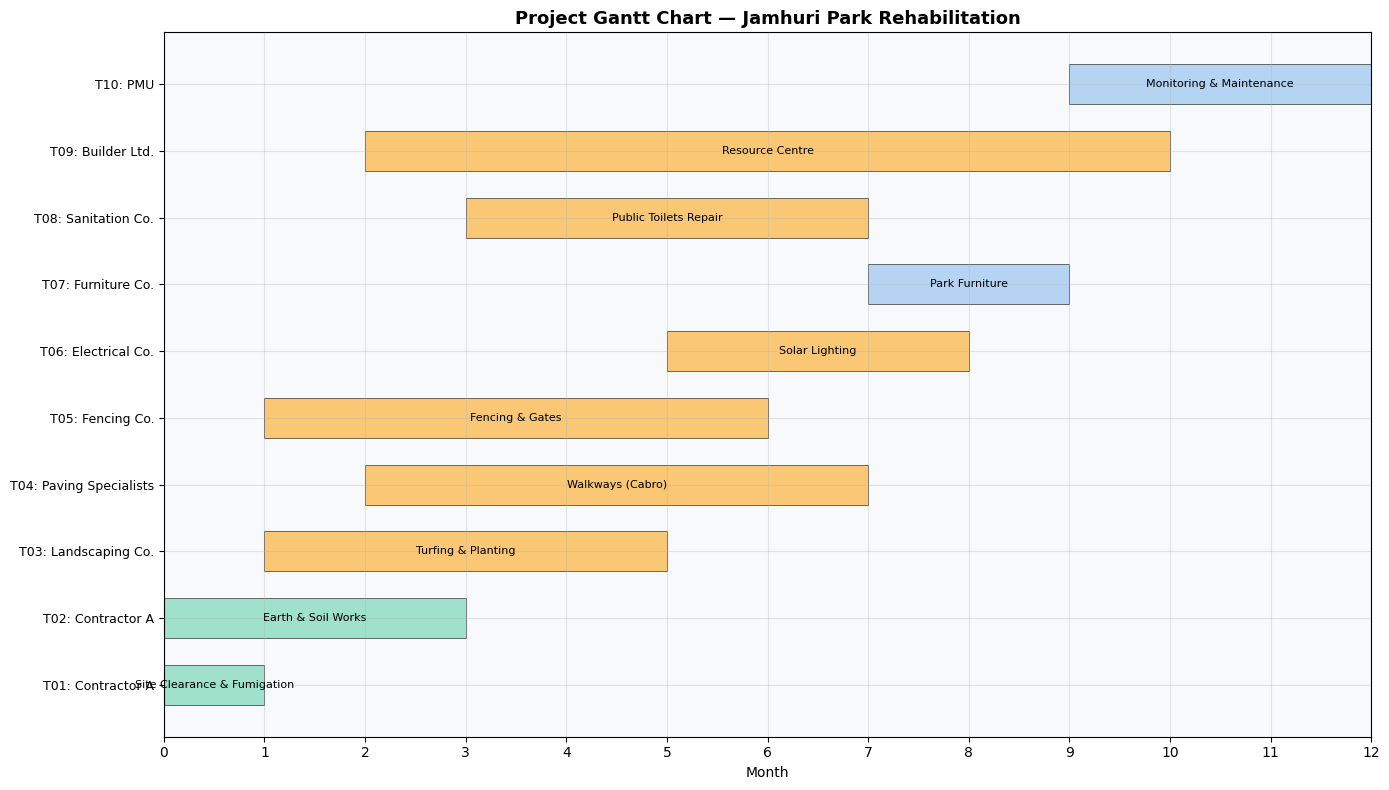

✓ Gantt chart saved → gantt_chart.png


In [ ]:
# ============================================================
# MODULE 3: Budget Planning, EVM & Resource Allocator
# ============================================================

class BudgetPlanner:
    """
    PMBOK-aligned Earned Value Management and resource allocator.
    Supports multi-task project planning with Gantt chart output.
    """

    def __init__(self, project_name, total_budget, duration_months):
        self.project_name  = project_name
        self.total_budget  = total_budget
        self.duration      = duration_months
        self.tasks         = []
        self.resources     = {}
        self.evm_snapshots = []

    # ── Task Management ────────────────────────────────────
    def add_task(self, task_id, name, budget_pct, start_month,
                 end_month, assigned_to, dependencies=None):
        """
        Add a work package.
        budget_pct: percentage of total budget allocated to this task
        start/end_month: 1-based month numbers
        """
        self.tasks.append({
            'id':          task_id,
            'name':        name,
            'budget':      self.total_budget * budget_pct / 100,
            'budget_pct':  budget_pct,
            'start':       start_month,
            'end':         end_month,
            'assigned':    assigned_to,
            'depends':     dependencies or [],
            'status':      'pending',
            'actual_cost': 0.0,
            'pct_done':    0,
        })

    def update_task(self, task_id, pct_done, actual_cost):
        """Update task progress for EVM computation."""
        for t in self.tasks:
            if t['id'] == task_id:
                t['pct_done']    = pct_done
                t['actual_cost'] = actual_cost
                t['status']      = ('complete' if pct_done == 100 else
                                    'in_progress' if pct_done > 0 else 'pending')

    # ── Resource Allocation ────────────────────────────────
    def allocate_resources(self, resources: dict):
        """
        resources = {
            'Role Name': {'count': N, 'rate_per_day': X, 'working_days': Y}
        }
        """
        self.resources = resources
        print(f"\nRESOURCE ALLOCATION — {self.project_name}")
        print("=" * 65)
        print(f"  {'Role':<22} {'Count':>5}  {'Rate/Day':>12}  {'Days':>6}  {'Total':>14}")
        print("-" * 65)
        total_resource_cost = 0
        for role, d in resources.items():
            subtotal = d['count'] * d['rate_per_day'] * d['working_days']
            total_resource_cost += subtotal
            print(f"  {role:<22} {d['count']:>5}  "
                  f"KES {d['rate_per_day']:>8,}  {d['working_days']:>6}  "
                  f"KES {subtotal:>10,}")
        print("=" * 65)
        print(f"  {'TOTAL RESOURCE COST':<22}                              "
              f"KES {total_resource_cost:>10,}")
        util = (total_resource_cost / self.total_budget) * 100
        print(f"  Budget Utilisation: {util:.1f}%")
        return total_resource_cost

    # ── EVM Computation ────────────────────────────────────
    def compute_evm(self, current_month, actual_cost_to_date):
        """
        Compute full EVM metrics at a point in time.
        current_month: which month we are at (1-based)
        actual_cost_to_date: total KES spent so far
        """
        # Planned Value: sum of budgets for tasks that should be done by now
        PV = sum(
            t['budget'] * min(1.0, max(0.0,
                (current_month - t['start'] + 1) / (t['end'] - t['start'] + 1)))
            for t in self.tasks
            if t['start'] <= current_month
        )
        # Earned Value: actual completion × budget
        EV = sum(t['budget'] * t['pct_done'] / 100 for t in self.tasks)
        AC = actual_cost_to_date

        CV  = EV - AC
        SV  = EV - PV
        CPI = EV / AC   if AC > 0 else 0
        SPI = EV / PV   if PV > 0 else 0
        EAC = self.total_budget / CPI if CPI > 0 else self.total_budget
        VAC = self.total_budget - EAC   # Variance at Completion
        TCPI= (self.total_budget - EV) / (self.total_budget - AC) if (self.total_budget - AC) > 0 else 0

        result = dict(month=current_month, PV=PV, EV=EV, AC=AC,
                      CV=CV, SV=SV, CPI=CPI, SPI=SPI, EAC=EAC, VAC=VAC, TCPI=TCPI)
        self.evm_snapshots.append(result)

        print(f"\nEVM REPORT — {self.project_name} (Month {current_month})")
        print("=" * 60)
        print(f"  {'Planned Value (PV)':<30} KES {PV:>14,.2f}")
        print(f"  {'Earned Value (EV)':<30} KES {EV:>14,.2f}")
        print(f"  {'Actual Cost (AC)':<30} KES {AC:>14,.2f}")
        print(f"  {'Cost Variance (CV)':<30} KES {CV:>14,.2f}  {'✓ Under budget' if CV>=0 else '✗ Over budget'}")
        print(f"  {'Schedule Variance (SV)':<30} KES {SV:>14,.2f}  {'✓ Ahead' if SV>=0 else '✗ Behind'}")
        print(f"  {'Cost Perf. Index (CPI)':<30} {CPI:.4f}  {'✓ Efficient' if CPI>=1 else '✗ Inefficient'}")
        print(f"  {'Schedule Perf. Index (SPI)':<30} {SPI:.4f}  {'✓ On time' if SPI>=0.95 else '✗ Delayed'}")
        print(f"  {'Estimate at Completion (EAC)':<30} KES {EAC:>14,.2f}")
        print(f"  {'Variance at Completion (VAC)':<30} KES {VAC:>14,.2f}")
        print(f"  {'To-Complete Perf. Index (TCPI)':<30} {TCPI:.4f}")
        print("=" * 60)
        return result

    # ── S-Curve ────────────────────────────────────────────
    def plot_s_curve(self):
        """Plot cumulative PV, EV, AC over project timeline."""
        months = list(range(1, self.duration + 1))
        planned = [self.total_budget * (m/self.duration)**1.5  for m in months]
        # Simulate slight underperformance
        actual  = [p * np.random.uniform(0.92, 1.08) for p in planned]
        earned  = [p * np.random.uniform(0.85, 1.02) for p in planned]

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(months, [v/1e6 for v in planned], 'b-o',
                label='Planned Value (PV)', linewidth=2.5, markersize=5)
        ax.plot(months, [v/1e6 for v in actual], 'r--s',
                label='Actual Cost (AC)', linewidth=2.5, markersize=5)
        ax.plot(months, [v/1e6 for v in earned], 'g--^',
                label='Earned Value (EV)', linewidth=2.5, markersize=5)
        ax.fill_between(months,
                         [v/1e6 for v in earned],
                         [v/1e6 for v in actual],
                         alpha=0.15, color='red', label='Cost Variance (–)')
        ax.set_title(f'S-Curve — {self.project_name}',
                     fontsize=14, fontweight='bold')
        ax.set_xlabel('Month', fontsize=12)
        ax.set_ylabel('Cumulative Cost (KES Millions)', fontsize=12)
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'KES {x:.1f}M'))
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('s_curve.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("✓ S-curve saved → s_curve.png")

    # ── Gantt Chart ────────────────────────────────────────
    def plot_gantt(self):
        """Draw a project Gantt chart."""
        if not self.tasks:
            print("No tasks added yet. Use add_task() first.")
            return
        fig, ax = plt.subplots(figsize=(14, 0.6 * len(self.tasks) + 2))
        colors = {'pending':'#B5D4F4','in_progress':'#FAC775','complete':'#9FE1CB'}
        for i, t in enumerate(self.tasks):
            dur   = t['end'] - t['start'] + 1
            color = colors.get(t['status'], '#B5D4F4')
            ax.barh(i, dur, left=t['start']-1, color=color,
                    edgecolor='#333', linewidth=0.5, height=0.6)
            ax.text(t['start']-1 + dur/2, i, t['name'],
                    ha='center', va='center', fontsize=8, fontweight='500')
        ax.set_yticks(range(len(self.tasks)))
        ax.set_yticklabels([f"{t['id']}: {t['assigned']}" for t in self.tasks],
                            fontsize=9)
        ax.set_xlabel('Month')
        ax.set_title(f'Project Gantt Chart — {self.project_name}',
                     fontsize=13, fontweight='bold')
        ax.set_xlim(0, self.duration)
        ax.xaxis.set_major_locator(plt.MultipleLocator(1))
        plt.tight_layout()
        plt.savefig('gantt_chart.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("✓ Gantt chart saved → gantt_chart.png")

# ─── USAGE: Jamhuri Park Rehabilitation ───────────────────
planner = BudgetPlanner('Jamhuri Park Rehabilitation', 29_607_491.76, 12)

planner.add_task('T01','Site Clearance & Fumigation', 2,  1,1,'Contractor A')
planner.add_task('T02','Earth & Soil Works',           8,  1,3,'Contractor A', ['T01'])
planner.add_task('T03','Turfing & Planting',           4,  2,5,'Landscaping Co.', ['T02'])
planner.add_task('T04','Walkways (Cabro)',             15,  3,7,'Paving Specialists', ['T02'])
planner.add_task('T05','Fencing & Gates',              17,  2,6,'Fencing Co.')
planner.add_task('T06','Solar Lighting',                5,  6,8,'Electrical Co.', ['T05'])
planner.add_task('T07','Park Furniture',                3,  8,9,'Furniture Co.', ['T04'])
planner.add_task('T08','Public Toilets Repair',         7,  4,7,'Sanitation Co.')
planner.add_task('T09','Resource Centre',               9,  3,10,'Builder Ltd.')
planner.add_task('T10','Monitoring & Maintenance',      7, 10,12,'PMU')

# Simulate progress at month 7
planner.update_task('T01', 100, 590000)
planner.update_task('T02', 100, 2400000)
planner.update_task('T03', 80, 950000)
planner.update_task('T04', 65, 4500000)
planner.update_task('T05', 90, 5100000)
planner.update_task('T06', 30, 400000)
planner.update_task('T07', 0, 0)
planner.update_task('T08', 70, 1500000)
planner.update_task('T09', 40, 2800000)
planner.update_task('T10', 0, 0)

resources = {
    'Project Manager':    {'count':1, 'rate_per_day':12000, 'working_days':240},
    'Site Engineer':      {'count':2, 'rate_per_day':8000,  'working_days':240},
    'Quantity Surveyor':  {'count':1, 'rate_per_day':7000,  'working_days':120},
    'Artisan/Fundi':      {'count':8, 'rate_per_day':2500,  'working_days':240},
    'General Labourer':   {'count':15,'rate_per_day':800,   'working_days':240},
    'Machine Operator':   {'count':2, 'rate_per_day':4000,  'working_days':120},
}
planner.allocate_resources(resources)
evm_result = planner.compute_evm(current_month=7, actual_cost_to_date=18_240_000)
planner.plot_s_curve()
planner.plot_gantt()

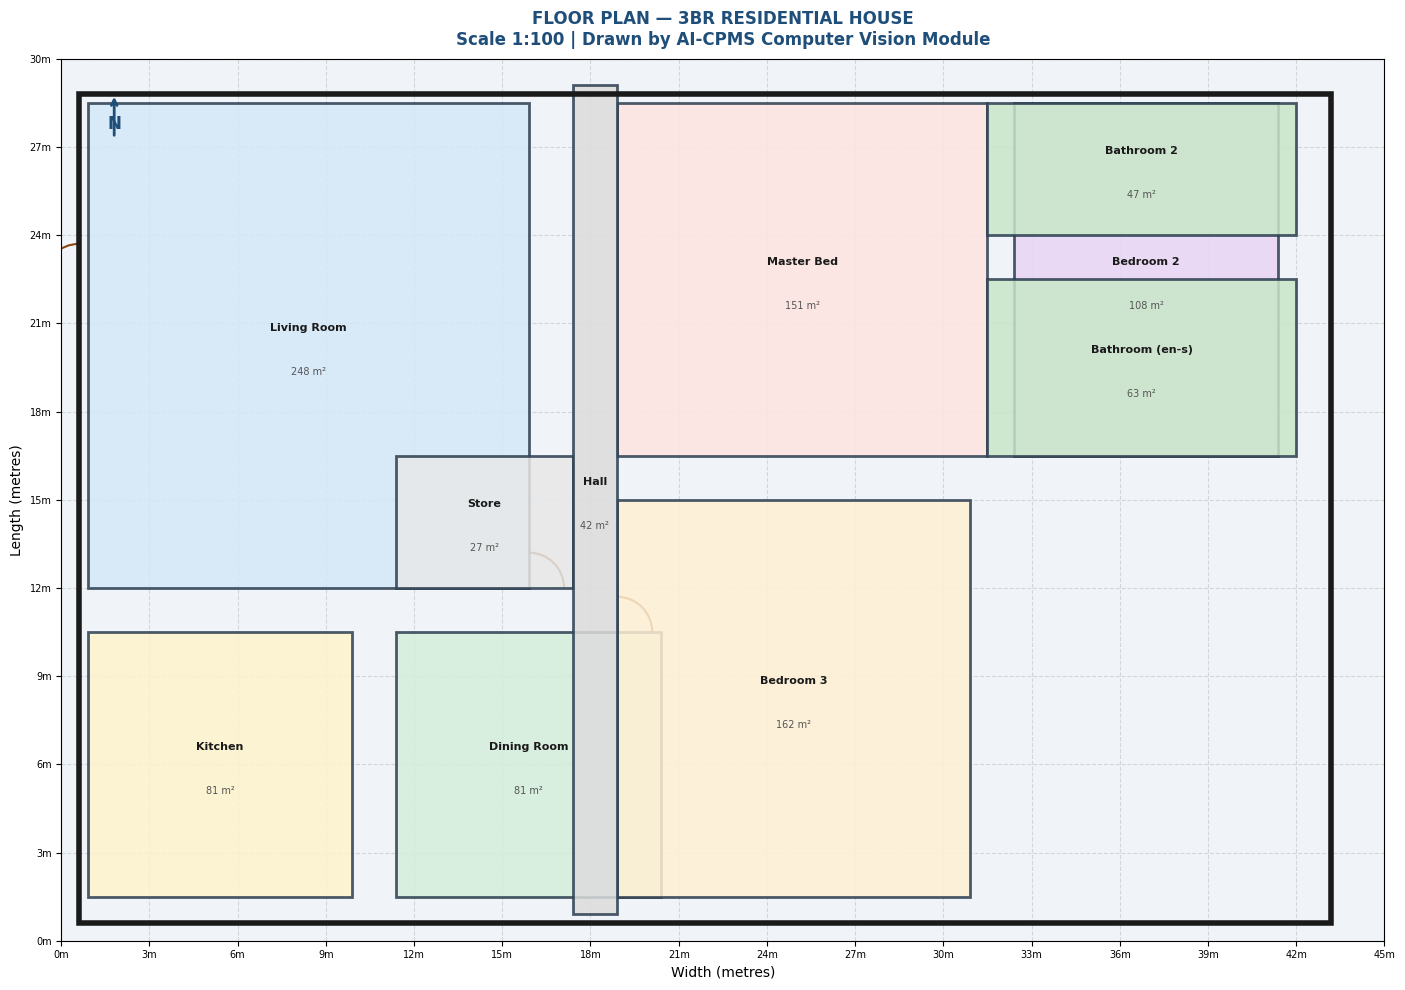

✓ Blueprint saved → house_blueprint.png

─── AUTOMATED QUANTITY TAKE-OFF ─────────────────────────────
  Room                          W      H   Area m²
  --------------------------------------------------
  Living Room                 5.0    5.5     247.5
  Kitchen                     3.0    3.0      81.0
  Dining Room                 3.0    3.0      81.0
  Master Bed                  4.2    4.0     151.2
  Bedroom 2                   3.0    4.0     108.0
  Bedroom 3                   4.0    4.5     162.0
  Bathroom (en-s)             3.5    2.0      63.0
  Bathroom 2                  3.5    1.5      47.2
  Store                       2.0    1.5      27.0
  Corridor                    0.5    9.4      42.3
  TOTAL FLOOR AREA                          1010.2 m²

  Estimated Perimeter:          127.1 m
  Cost Rate (residential):         KES 45,000/m²
  Base Construction Cost:       KES     45,461,250
  + 10% Contingency:            KES     50,007,375
  + 14% VAT:                    KES  

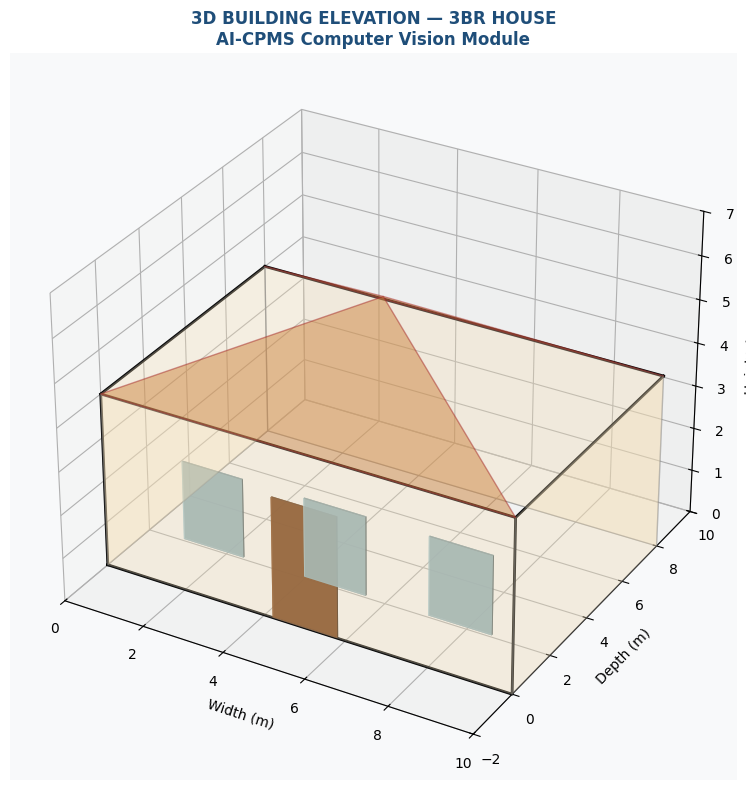

✓ 3D elevation saved → elevation_3d.png


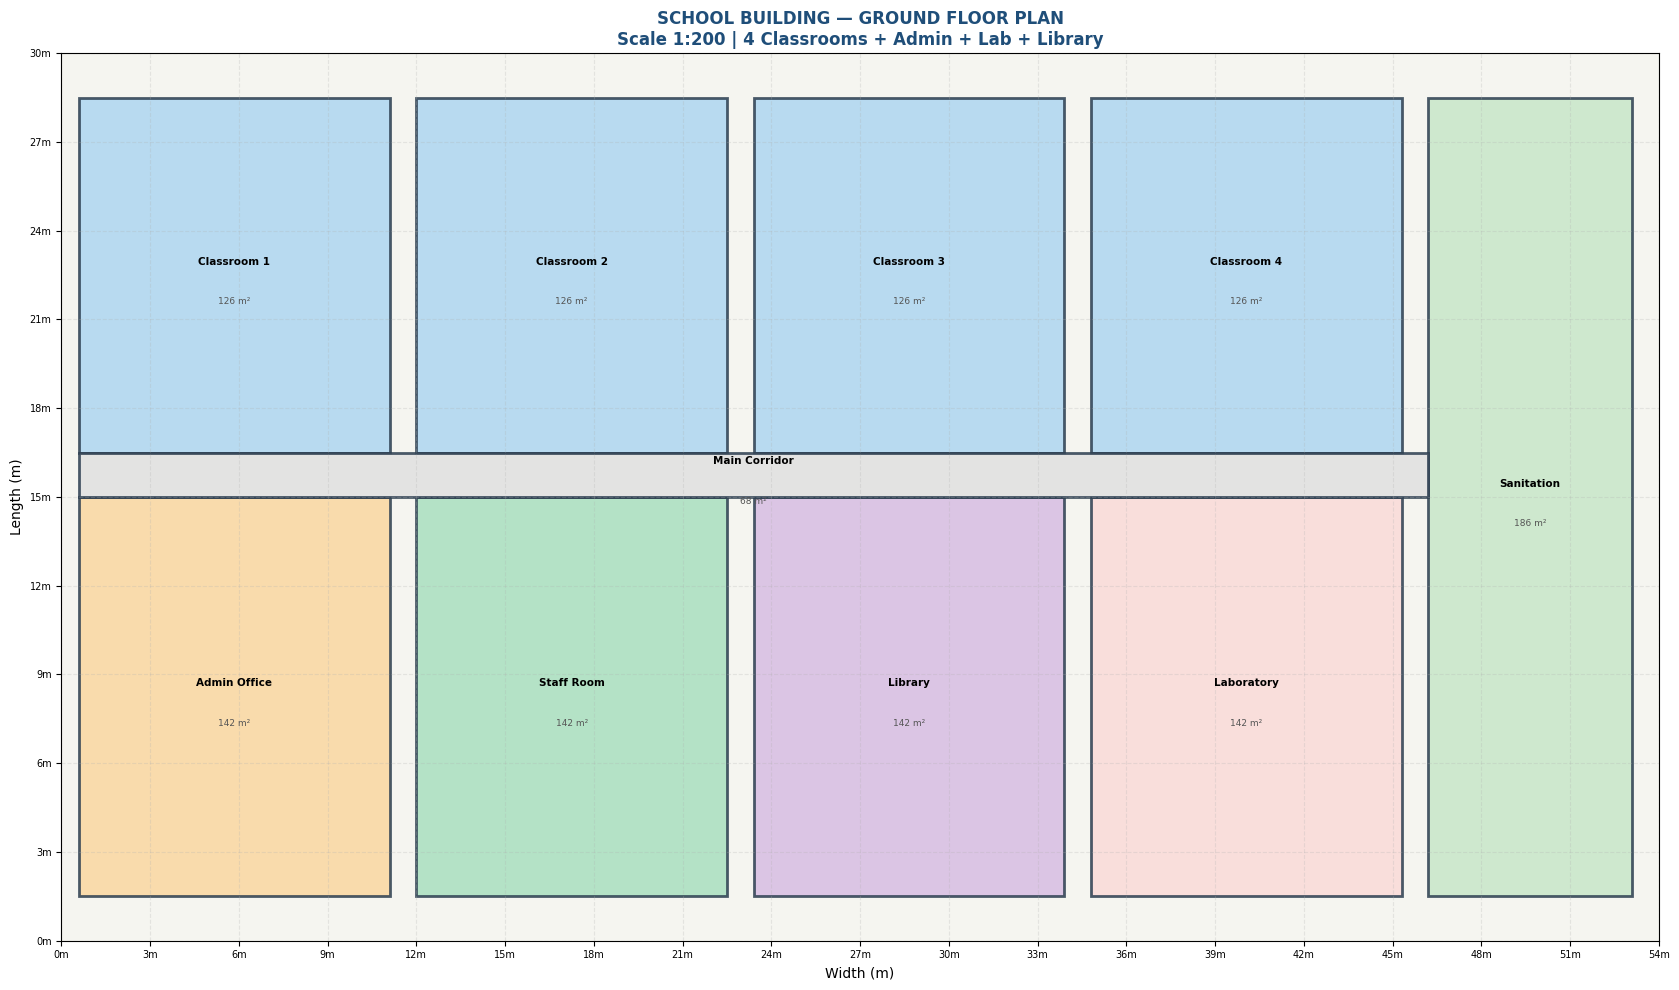

✓ School plan saved → school_plan.png

─── AUTOMATED QUANTITY TAKE-OFF ─────────────────────────────
  Room                          W      H   Area m²
  --------------------------------------------------
  Classroom 1                 3.5    4.0     126.0
  Classroom 2                 3.5    4.0     126.0
  Classroom 3                 3.5    4.0     126.0
  Classroom 4                 3.5    4.0     126.0
  Admin Office                3.5    4.5     141.8
  Staff Room                  3.5    4.5     141.8
  Library                     3.5    4.5     141.8
  Laboratory                  3.5    4.5     141.8
  Sanitation                  2.3    9.0     186.3
  Main Corridor              15.2    0.5      68.4
  TOTAL FLOOR AREA                          1325.7 m²

  Estimated Perimeter:          145.6 m
  Cost Rate (school):         KES 38,000/m²
  Base Construction Cost:       KES     50,376,600
  + 10% Contingency:            KES     55,414,260
  + 14% VAT:                    KES     63,1

(1325.7, 63172256.400000006)

In [ ]:
# ============================================================
# MODULE 4: Computer Vision Building Design Analyzer
# ============================================================

class BuildingDesignCV:
    """
    Generates architectural floor plans and performs automated
    quantity take-off using Matplotlib + OpenCV.
    Scale: 1 drawing unit = 3 metres (unless noted).
    """

    CONSTRUCTION_COST_PER_M2 = {
        'residential': 45000,    # KES/m²
        'school':      38000,
        'stadium':     120000,
        'office':      55000,
    }

    # ── House Blueprint ───────────────────────────────────
    def generate_house_blueprint(self, house_type='3BR',
                                  save_path='house_blueprint.png'):
        """Generate a 3-bedroom house floor plan."""
        fig, ax = plt.subplots(figsize=(15, 10))
        ax.set_xlim(0, 15)
        ax.set_ylim(0, 10)
        ax.set_facecolor('#F0F4F8')
        ax.set_aspect('equal')

        # Room definitions: x, y, width, height (drawing units), colour
        rooms = {
            'Living Room':     (0.3, 4.0, 5.0, 5.5, '#D4E8F7'),
            'Kitchen':         (0.3, 0.5, 3.0, 3.0, '#FFF3CD'),
            'Dining Room':     (3.8, 0.5, 3.0, 3.0, '#D4EDDA'),
            'Master Bed':      (6.3, 5.5, 4.2, 4.0, '#FFE4E1'),
            'Bedroom 2':       (10.8,'5.5',3.0, 4.0, '#E8D5F5'),
            'Bedroom 3':       (6.3, 0.5, 4.0, 4.5, '#FFF0D4'),
            'Bathroom (en-s)': (10.5, 5.5, 3.5, 2.0, '#C8E6C9'),
            'Bathroom 2':      (10.5, 8.0, 3.5, 1.5, '#C8E6C9'),
            'Store':           (3.8, 4.0, 2.0, 1.5, '#E8E8E8'),
            'Corridor':        (5.8, 0.3, 0.5, 9.4, '#DCDCDC'),
        }

        all_room_data = {}
        for name, (x, y, w, h, clr) in rooms.items():
            x, y, w, h = float(x), float(y), float(w), float(h)
            rect = patches.Rectangle(
                (x, y), w, h,
                linewidth=2, edgecolor='#2C3E50',
                facecolor=clr, alpha=0.85, zorder=2
            )
            ax.add_patch(rect)
            area_m2 = w * h * 9   # scale: 1 unit = 3m, area = (3m)²= 9m²
            label   = name if name != 'Corridor' else 'Hall'
            ax.text(x + w/2, y + h/2 + 0.2, label,
                    ha='center', va='center', fontsize=8,
                    fontweight='bold', color='#1A1A1A', zorder=3)
            ax.text(x + w/2, y + h/2 - 0.3, f'{area_m2:.0f} m²',
                    ha='center', va='center', fontsize=7,
                    color='#555', zorder=3)
            all_room_data[name] = {'w':w,'h':h,'area_m2':area_m2,'color':clr}

        # Outer walls
        outer = patches.Rectangle((0.2,0.2), 14.2, 9.4,
            linewidth=4, edgecolor='#1A1A1A', facecolor='none', zorder=4)
        ax.add_patch(outer)

        # Door swing indicators
        for (x, y, angle) in [(5.3,4.0,0), (0.2,7.5,90), (6.3,3.5,0)]:
            arc = patches.Arc((x,y), 0.8, 0.8, angle=angle,
                               theta1=0, theta2=90, color='#8B4513', linewidth=1.5)
            ax.add_patch(arc)

        # Compass
        ax.annotate('N', xy=(0.6, 9.2), fontsize=12, fontweight='bold',
                    color='#1F4E79', ha='center')
        ax.annotate('', xy=(0.6, 9.6), xytext=(0.6, 9.1),
                    arrowprops=dict(arrowstyle='->', color='#1F4E79', lw=2))

        # Grid
        ax.set_xticks(range(0, 16))
        ax.set_yticks(range(0, 11))
        ax.set_xticklabels([f'{i*3}m' for i in range(16)], fontsize=7)
        ax.set_yticklabels([f'{i*3}m' for i in range(11)], fontsize=7)
        ax.grid(True, alpha=0.25, color='gray', linestyle='--', zorder=1)
        ax.set_title(
            f'FLOOR PLAN — {house_type} RESIDENTIAL HOUSE\n'
            'Scale 1:100 | Drawn by AI-CPMS Computer Vision Module',
            fontsize=12, fontweight='bold', color='#1F4E79', pad=10
        )
        ax.set_xlabel('Width (metres)', fontsize=10)
        ax.set_ylabel('Length (metres)', fontsize=10)

        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"✓ Blueprint saved → {save_path}")
        return all_room_data

    # ── Quantity Take-off ──────────────────────────────────
    def analyze_floor_plan(self, rooms: dict, ptype='residential'):
        """Automated quantity take-off from room geometry."""
        print("\n─── AUTOMATED QUANTITY TAKE-OFF ─────────────────────────────")
        print(f"  {'Room':<25} {'W':>5}  {'H':>5}  {'Area m²':>8}")
        print("  " + "-"*50)
        total_area = 0
        for name, props in rooms.items():
            area = props['area_m2']
            total_area += area
            print(f"  {name:<25} {props['w']:>5.1f}  {props['h']:>5.1f}  {area:>8.1f}")
        print("  " + "="*50)
        print(f"  {'TOTAL FLOOR AREA':<25}               {total_area:>8.1f} m²")

        perimeter = 4 * (total_area ** 0.5)
        cost_psm  = self.CONSTRUCTION_COST_PER_M2.get(ptype, 45000)
        est_cost  = total_area * cost_psm
        est_cost_contingency = est_cost * 1.10
        est_cost_vat = est_cost_contingency * 1.14

        print(f"\n  Estimated Perimeter:          {perimeter:.1f} m")
        print(f"  Cost Rate ({ptype}):         KES {cost_psm:,}/m²")
        print(f"  Base Construction Cost:       KES {est_cost:>14,.0f}")
        print(f"  + 10% Contingency:            KES {est_cost_contingency:>14,.0f}")
        print(f"  + 14% VAT:                    KES {est_cost_vat:>14,.0f}")
        print("─────────────────────────────────────────────────────────────")
        return total_area, est_cost_vat

    # ── School Plan ────────────────────────────────────────
    def generate_school_plan(self, save_path='school_plan.png'):
        """Generate a primary/secondary school floor plan."""
        fig, ax = plt.subplots(figsize=(18, 10))
        ax.set_xlim(0, 18); ax.set_ylim(0, 10)
        ax.set_facecolor('#F5F5F0'); ax.set_aspect('equal')

        rooms = {
            'Classroom 1': (0.2, 5.5, 3.5, 4.0, '#AED6F1'),
            'Classroom 2': (4.0, 5.5, 3.5, 4.0, '#AED6F1'),
            'Classroom 3': (7.8, 5.5, 3.5, 4.0, '#AED6F1'),
            'Classroom 4': (11.6,5.5, 3.5, 4.0, '#AED6F1'),
            'Admin Office': (0.2, 0.5, 3.5, 4.5, '#FAD7A0'),
            'Staff Room':  (4.0, 0.5, 3.5, 4.5, '#A9DFBF'),
            'Library':     (7.8, 0.5, 3.5, 4.5, '#D7BDE2'),
            'Laboratory':  (11.6,0.5, 3.5, 4.5, '#FADBD8'),
            'Sanitation':  (15.4,0.5, 2.3, 9.0, '#C8E6C9'),
            'Main Corridor':(0.2,5.0,15.2, 0.5, '#E0E0E0'),
        }
        rooms_out = {}
        for name,(x,y,w,h,clr) in rooms.items():
            ax.add_patch(patches.Rectangle((x,y),w,h,linewidth=2,
                edgecolor='#2C3E50',facecolor=clr,alpha=0.85))
            area = w*h*9
            ax.text(x+w/2,y+h/2+0.15,name,ha='center',va='center',
                    fontsize=7.5,fontweight='bold')
            ax.text(x+w/2,y+h/2-0.3,f'{area:.0f} m²',ha='center',
                    va='center',fontsize=6.5,color='#555')
            rooms_out[name]={'w':w,'h':h,'area_m2':area}

        ax.set_title('SCHOOL BUILDING — GROUND FLOOR PLAN\n'
                     'Scale 1:200 | 4 Classrooms + Admin + Lab + Library',
                     fontsize=12,fontweight='bold',color='#1F4E79')
        ax.set_xlabel('Width (m)'); ax.set_ylabel('Length (m)')
        ax.set_xticks(range(0,19)); ax.set_xticklabels([f'{i*3}m' for i in range(19)],fontsize=7)
        ax.set_yticks(range(0,11)); ax.set_yticklabels([f'{i*3}m' for i in range(11)],fontsize=7)
        ax.grid(True,alpha=0.25,linestyle='--')
        plt.tight_layout()
        plt.savefig(save_path,dpi=150,bbox_inches='tight')
        plt.show()
        print(f"✓ School plan saved → {save_path}")
        return rooms_out

    # ── 3D Elevation ───────────────────────────────────────
    def generate_3d_elevation(self, save_path='elevation_3d.png'):
        """Simple 3D perspective elevation drawing."""
        fig = plt.figure(figsize=(14, 8))
        ax  = fig.add_subplot(111, projection='3d')

        # Ground floor walls (box)
        x = [0,10,10,0,0]; y=[0,0,0,0,0]; z=[0,0,4,4,0]
        ax.plot(x,y,z,'k-',linewidth=2)         # front wall
        ax.plot([0,0],[0,8],[4,4],'k-',lw=2)    # left side
        ax.plot([10,10],[0,8],[4,4],'k-',lw=2)  # right side
        ax.plot([0,10],[8,8],[4,4],'k-',lw=2)   # back top

        # Fill walls
        from mpl_toolkits.mplot3d.art3d import Poly3DCollection
        verts = [
            [(0,0,0),(10,0,0),(10,0,4),(0,0,4)],   # front
            [(0,8,0),(10,8,0),(10,8,4),(0,8,4)],   # back
            [(0,0,0),(0,8,0),(0,8,4),(0,0,4)],     # left
            [(10,0,0),(10,8,0),(10,8,4),(10,0,4)], # right
        ]
        poly = Poly3DCollection(verts, alpha=0.3, facecolor='#F5DEB3', edgecolor='gray')
        ax.add_collection3d(poly)

        # Roof
        roof = [[(0,0,4),(10,0,4),(5,4,6)],
                [(0,8,4),(10,8,4),(5,4,6)]]
        rpoly = Poly3DCollection(roof,alpha=0.5,facecolor='#CD853F',edgecolor='brown')
        ax.add_collection3d(rpoly)

        # Windows
        for wx in [2, 5, 8]:
            ax.bar3d(wx,0,1.2, 1.5,0.05,1.8, color='lightblue',alpha=0.7)

        # Door
        ax.bar3d(4.2,0,0,1.6,0.05,2.8,color='#8B4513',alpha=0.8)

        ax.set_title('3D BUILDING ELEVATION — 3BR HOUSE\nAI-CPMS Computer Vision Module',
                     fontsize=12,fontweight='bold',color='#1F4E79')
        ax.set_xlabel('Width (m)'); ax.set_ylabel('Depth (m)'); ax.set_zlabel('Height (m)')
        ax.set_xlim(0,10); ax.set_ylim(-2,10); ax.set_zlim(0,7)
        plt.tight_layout()
        plt.savefig(save_path,dpi=150,bbox_inches='tight')
        plt.show()
        print(f"✓ 3D elevation saved → {save_path}")

# ─── USAGE ────────────────────────────────────────────────
cv = BuildingDesignCV()

# House floor plan + take-off
house_rooms = cv.generate_house_blueprint('3BR', 'house_blueprint.png')
total_area, est_cost = cv.analyze_floor_plan(house_rooms, 'residential')

# 3D elevation
cv.generate_3d_elevation('elevation_3d.png')

# School plan
school_rooms = cv.generate_school_plan('school_plan.png')
cv.analyze_floor_plan(school_rooms, 'school')


PORTFOLIO SUMMARY — Kisumu City Infrastructure Programme 2025-26
  Project                                Budget          Actual     CPI     SPI   Delay  Risk    
----------------------------------------------------------------------------------------------------
  JKG Sports Ground              KES    111.33M  KES     78.00M   0.928   0.929    15d  MEDIUM  
  Jamhuri Park                   KES     29.61M  KES     18.50M   0.928   0.967     5d  MEDIUM  
  Oile Park                      KES     27.63M  KES     16.00M   0.864   0.909    20d  MEDIUM  
  Botanical Gardens              KES     45.58M  KES     18.00M   0.886   0.875    30d  MEDIUM  
  Streetscaping                  KES      8.93M  KES      6.50M   1.127   1.025     0d  LOW     
  PORTFOLIO TOTAL                KES    223.08M  KES    137.00M


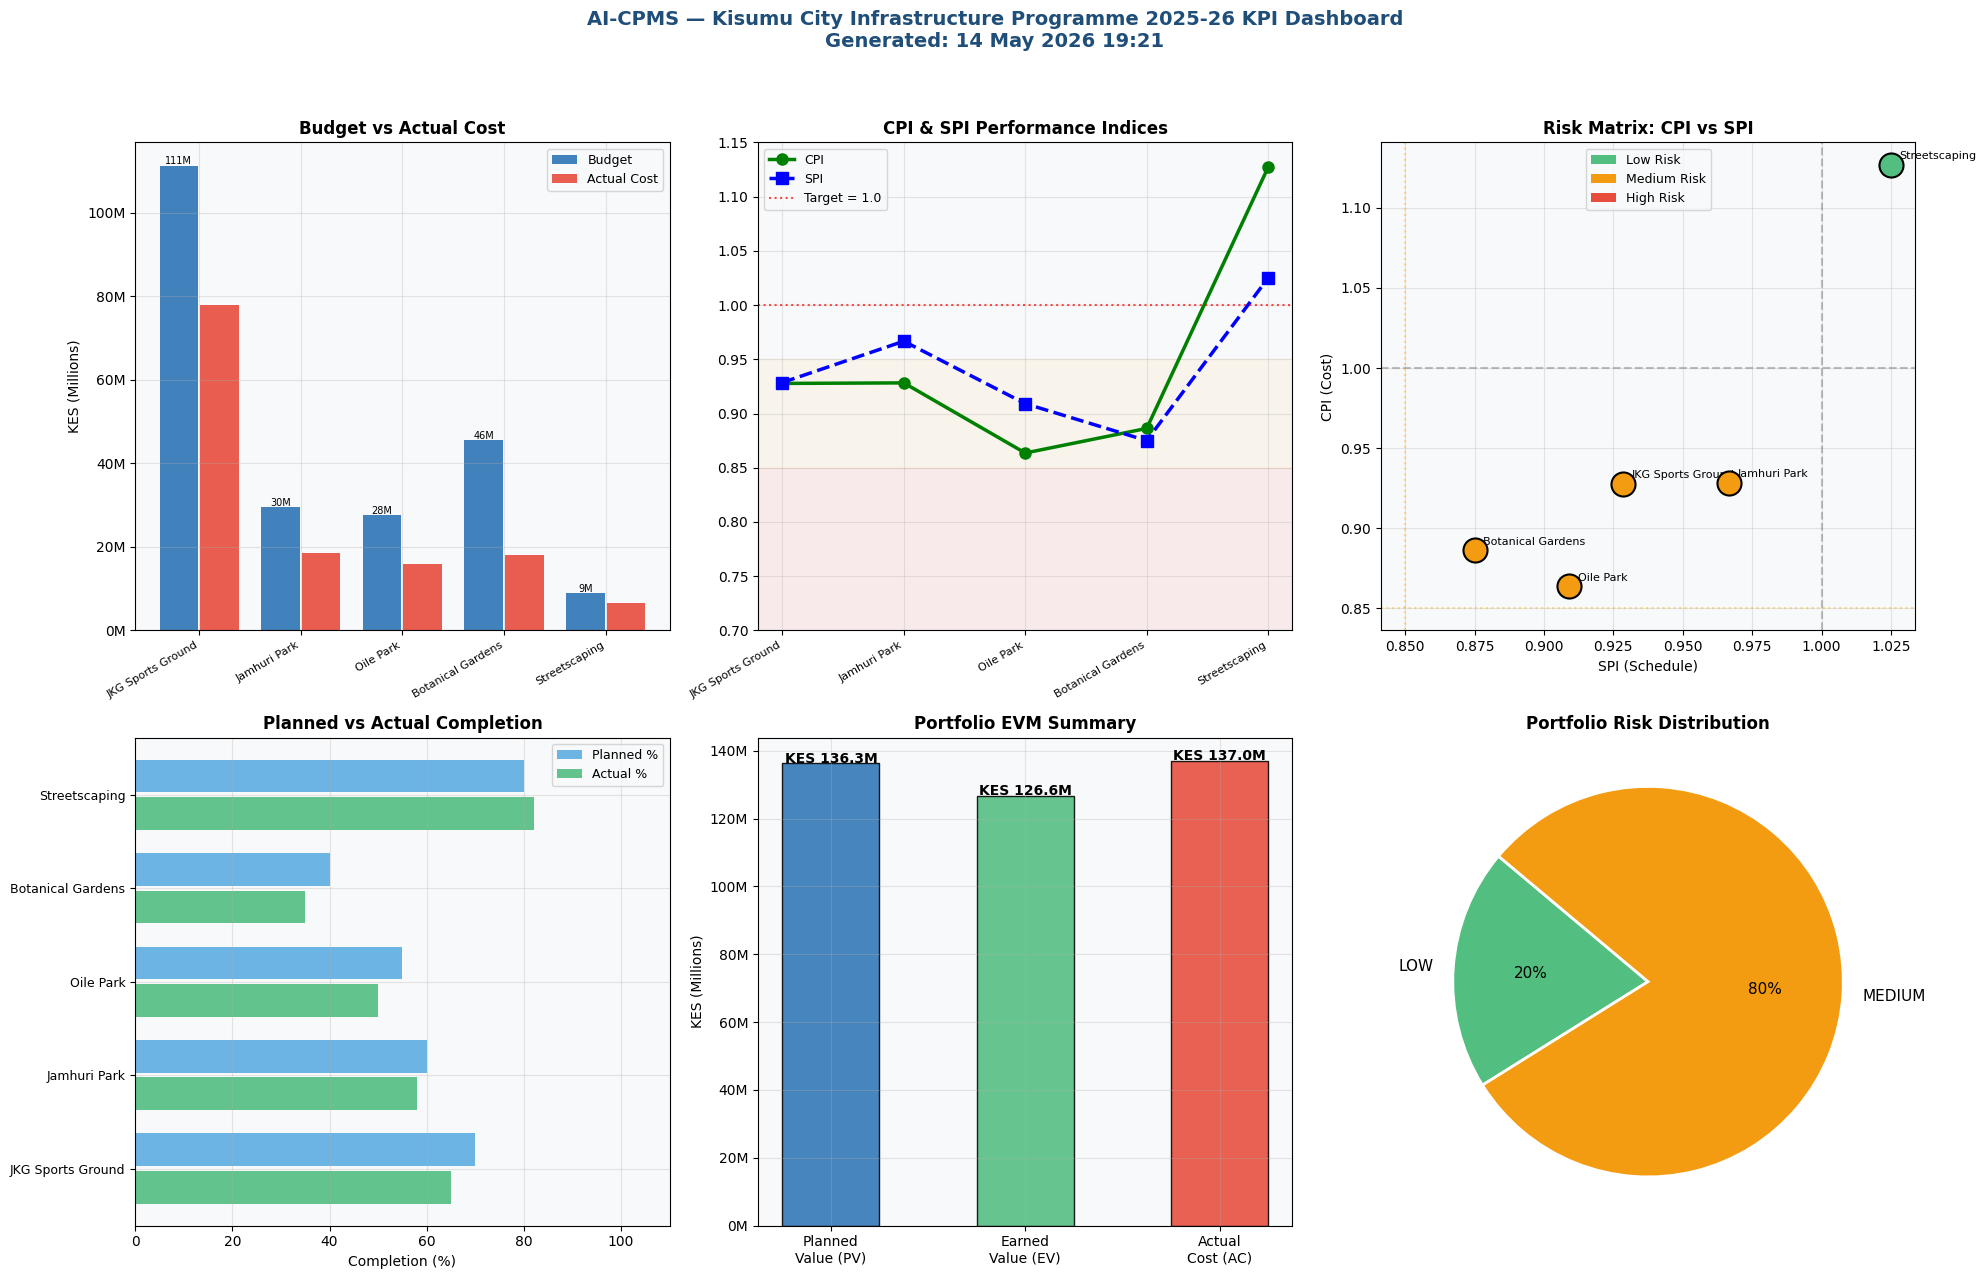

✓ Dashboard saved → kpi_dashboard.png


In [ ]:
# ============================================================
# MODULE 5: KPI Dashboard & Risk Assessment Engine
# ============================================================

class ProjectDashboard:
    """Real-time multi-project KPI monitoring and risk dashboard."""

    RISK_THRESHOLDS = {
        'LOW':    {'cpi_min':0.95, 'spi_min':0.95},
        'MEDIUM': {'cpi_min':0.85, 'spi_min':0.85},
        'HIGH':   {'cpi_min':0.00, 'spi_min':0.00},
    }

    def __init__(self, portfolio_name='Project Portfolio'):
        self.portfolio_name = portfolio_name
        self.projects = []

    def add_project(self, name, budget, planned_pct, actual_pct,
                    actual_cost, delay_days=0, project_manager='TBD'):
        PV = budget * planned_pct / 100
        EV = budget * actual_pct  / 100
        AC = actual_cost
        self.projects.append({
            'name':    name, 'budget':  budget,
            'pct_p':  planned_pct, 'pct_a': actual_pct,
            'AC':     AC, 'PV': PV, 'EV': EV,
            'delay':  delay_days, 'pm': project_manager,
        })

    def _kpis(self, p):
        CPI = p['EV'] / p['AC'] if p['AC'] > 0 else 1.0
        SPI = p['EV'] / p['PV'] if p['PV'] > 0 else 1.0
        CV  = p['EV'] - p['AC']
        SV  = p['EV'] - p['PV']
        if CPI >= 0.95 and SPI >= 0.95:
            risk = 'LOW'
        elif CPI >= 0.85 and SPI >= 0.85:
            risk = 'MEDIUM'
        else:
            risk = 'HIGH'
        return CPI, SPI, CV, SV, risk

    def summary_table(self):
        """Print a summary table of all projects."""
        print(f"\nPORTFOLIO SUMMARY — {self.portfolio_name}")
        print("=" * 100)
        print(f"  {'Project':<30} {'Budget':>14}  {'Actual':>14}  "
              f"{'CPI':>6}  {'SPI':>6}  {'Delay':>6}  {'Risk':<8}")
        print("-" * 100)
        for p in self.projects:
            cpi, spi, cv, sv, risk = self._kpis(p)
            print(f"  {p['name']:<30} KES {p['budget']/1e6:>9.2f}M  "
                  f"KES {p['AC']/1e6:>9.2f}M  {cpi:>6.3f}  {spi:>6.3f}  "
                  f"{p['delay']:>4}d  {risk:<8}")
        total_budget = sum(p['budget'] for p in self.projects)
        total_actual = sum(p['AC'] for p in self.projects)
        print("=" * 100)
        print(f"  {'PORTFOLIO TOTAL':<30} KES {total_budget/1e6:>9.2f}M  "
              f"KES {total_actual/1e6:>9.2f}M")

    def generate_dashboard(self, save_path='kpi_dashboard.png'):
        """6-panel portfolio KPI dashboard."""
        n = len(self.projects)
        names  = [p['name'][:18] for p in self.projects]
        budgets= [p['budget']/1e6  for p in self.projects]
        actuals= [p['AC']/1e6      for p in self.projects]
        delays = [p['delay']       for p in self.projects]
        cpis   = [self._kpis(p)[0] for p in self.projects]
        spis   = [self._kpis(p)[1] for p in self.projects]
        risks  = [self._kpis(p)[4] for p in self.projects]
        x = np.arange(n)

        RISK_CLRS = {'LOW':'#52BE80','MEDIUM':'#F39C12','HIGH':'#E74C3C'}

        fig = plt.figure(figsize=(20, 13))
        fig.suptitle(
            f'AI-CPMS — {self.portfolio_name} KPI Dashboard\n'
            f'Generated: {datetime.datetime.now().strftime("%d %B %Y %H:%M")}',
            fontsize=14, fontweight='bold', color='#1F4E79', y=0.98
        )

        # ── Panel 1: Budget vs Actual ─────────────────────
        ax1 = fig.add_subplot(2, 3, 1)
        bars1 = ax1.bar(x-0.2, budgets, 0.38, label='Budget',
                        color='#2E75B6', alpha=0.9)
        bars2 = ax1.bar(x+0.2, actuals, 0.38, label='Actual Cost',
                        color='#E74C3C', alpha=0.9)
        ax1.set_title('Budget vs Actual Cost', fontweight='bold')
        ax1.set_xticks(x)
        ax1.set_xticklabels(names, rotation=30, ha='right', fontsize=8)
        ax1.set_ylabel('KES (Millions)')
        ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}M'))
        ax1.legend(fontsize=9); ax1.grid(axis='y',alpha=0.3)
        for bar in bars1:
            ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                     f'{bar.get_height():.0f}M', ha='center', fontsize=7)

        # ── Panel 2: CPI & SPI ────────────────────────────
        ax2 = fig.add_subplot(2, 3, 2)
        ax2.plot(names, cpis, 'g-o', label='CPI', lw=2.5, ms=8)
        ax2.plot(names, spis, 'b--s', label='SPI', lw=2.5, ms=8)
        ax2.axhline(1.0, color='red', ls=':', alpha=0.7, label='Target = 1.0')
        ax2.axhspan(0, 0.85, alpha=0.06, color='red')
        ax2.axhspan(0.85, 0.95, alpha=0.06, color='orange')
        ax2.set_title('CPI & SPI Performance Indices', fontweight='bold')
        ax2.set_xticklabels(names, rotation=30, ha='right', fontsize=8)
        ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
        ax2.set_ylim(0.7, 1.15)

        # ── Panel 3: Risk Matrix ──────────────────────────
        ax3 = fig.add_subplot(2, 3, 3)
        for i, p in enumerate(self.projects):
            cpi, spi, _, _, risk = self._kpis(p)
            ax3.scatter(spi, cpi, s=300, c=RISK_CLRS[risk],
                        zorder=5, edgecolors='black', lw=1.5)
            ax3.annotate(names[i], (spi, cpi),
                         textcoords='offset points', xytext=(6,4), fontsize=8)
        ax3.axhline(1, color='gray', ls='--', alpha=0.5)
        ax3.axvline(1, color='gray', ls='--', alpha=0.5)
        ax3.axhline(0.85, color='orange', ls=':', alpha=0.4)
        ax3.axvline(0.85, color='orange', ls=':', alpha=0.4)
        ax3.set_xlabel('SPI (Schedule)', fontsize=10)
        ax3.set_ylabel('CPI (Cost)', fontsize=10)
        ax3.set_title('Risk Matrix: CPI vs SPI', fontweight='bold')
        from matplotlib.patches import Patch
        ax3.legend(handles=[
            Patch(fc='#52BE80', label='Low Risk'),
            Patch(fc='#F39C12', label='Medium Risk'),
            Patch(fc='#E74C3C', label='High Risk'),
        ], fontsize=9)
        ax3.grid(alpha=0.3)

        # ── Panel 4: Completion % ─────────────────────────
        ax4 = fig.add_subplot(2, 3, 4)
        planned_pcts = [p['pct_p'] for p in self.projects]
        actual_pcts  = [p['pct_a'] for p in self.projects]
        ax4.barh([i+0.2 for i in range(n)], planned_pcts, 0.35,
                 label='Planned %', color='#5DADE2', alpha=0.9)
        ax4.barh([i-0.2 for i in range(n)], actual_pcts,  0.35,
                 label='Actual %',  color='#52BE80', alpha=0.9)
        ax4.set_yticks(range(n))
        ax4.set_yticklabels(names, fontsize=9)
        ax4.set_xlabel('Completion (%)')
        ax4.set_title('Planned vs Actual Completion', fontweight='bold')
        ax4.legend(fontsize=9); ax4.grid(axis='x', alpha=0.3)
        ax4.set_xlim(0, 110)

        # ── Panel 5: EVM Waterfall ────────────────────────
        ax5 = fig.add_subplot(2, 3, 5)
        tot_PV = sum(p['PV'] for p in self.projects)/1e6
        tot_EV = sum(p['EV'] for p in self.projects)/1e6
        tot_AC = sum(p['AC'] for p in self.projects)/1e6
        evm_labels = ['Planned\nValue (PV)', 'Earned\nValue (EV)', 'Actual\nCost (AC)']
        evm_vals   = [tot_PV, tot_EV, tot_AC]
        evm_colors = ['#2E75B6', '#52BE80', '#E74C3C']
        bars5 = ax5.bar(evm_labels, evm_vals, color=evm_colors,
                        edgecolor='black', alpha=0.88, width=0.5)
        ax5.set_title('Portfolio EVM Summary', fontweight='bold')
        ax5.set_ylabel('KES (Millions)')
        ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}M'))
        for bar, val in zip(bars5, evm_vals):
            ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                     f'KES {val:.1f}M', ha='center', fontweight='bold', fontsize=10)
        ax5.grid(axis='y', alpha=0.3)

        # ── Panel 6: Risk Pie ─────────────────────────────
        ax6 = fig.add_subplot(2, 3, 6)
        risk_counts = {'LOW': risks.count('LOW'),
                       'MEDIUM': risks.count('MEDIUM'),
                       'HIGH': risks.count('HIGH')}
        wedge_props = {'edgecolor':'white','linewidth':2}
        ax6.pie(
            [v for v in risk_counts.values() if v > 0],
            labels=[k for k,v in risk_counts.items() if v > 0],
            colors=[RISK_CLRS[k] for k,v in risk_counts.items() if v > 0],
            autopct='%1.0f%%', startangle=140,
            wedgeprops=wedge_props, textprops={'fontsize':11}
        )
        ax6.set_title('Portfolio Risk Distribution', fontweight='bold')

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"✓ Dashboard saved → {save_path}")

# ─── USAGE: Real Kisumu City Portfolio ────────────────────
dash = ProjectDashboard('Kisumu City Infrastructure Programme 2025-26')

dash.add_project('JKG Sports Ground',  111_328_291, 70, 65, 78_000_000, 15, 'Eng. Kamau')
dash.add_project('Jamhuri Park',        29_607_492, 60, 58, 18_500_000,  5, 'Eng. Auma')
dash.add_project('Oile Park',           27_634_987, 55, 50, 16_000_000, 20, 'Eng. Ochieng')
dash.add_project('Botanical Gardens',   45_579_640, 40, 35, 18_000_000, 30, 'Eng. Adhiambo')
dash.add_project('Streetscaping',        8_934_123, 80, 82,  6_500_000,  0, 'Eng. Onyango')

dash.summary_table()
dash.generate_dashboard('kpi_dashboard.png')

╔══════════════════════════════════════════════════════════╗
║    AI-CPMS: AI-Driven Construction Project Mgmt System  ║
║    Author: Henry Kissinger Onyango | BSBI/UCA | 2026    ║
╚══════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STEP 1 — AI Business Proposal Generator
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BUSINESS PROPOSAL: JOMO KENYATTA SPORTS GROUND REHABILITATION
Ref: PROP/20260514/STA001
  Client:           County Government of Kisumu / KUSP
  Location:         Kisumu City Centre, Kenya
  Date:             14 May 2026
  Estimated Budget: KES  111,328,291.44
  Timeline:         290 months
  Validity:         60 days

INTRODUCTION
  We are pleased to submit this proposal for the Jomo Kenyatta Sports Ground Rehabilitation located in Kisumu City Centre, Kenya. This proposal covers all works required for the successful delivery of the project in accordance with client specifications and Ken

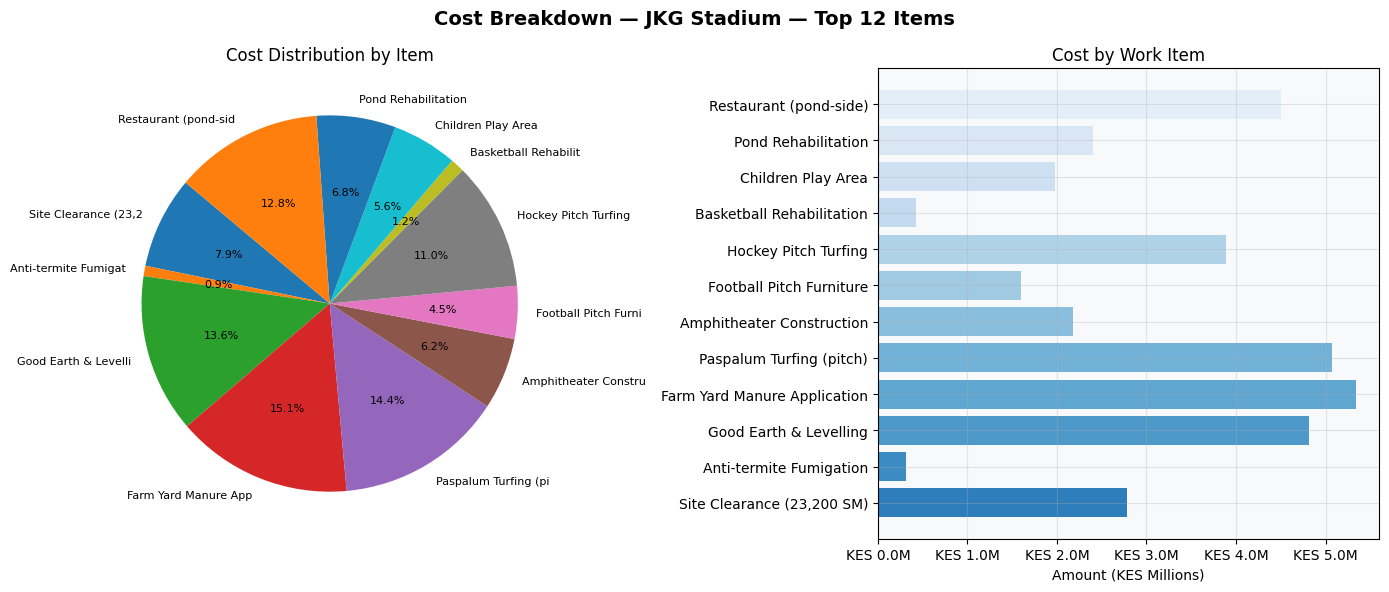

✓ Chart saved → boq_breakdown.png

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STEP 3 — Budget Planning & Earned Value Management
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

RESOURCE ALLOCATION — JKG Sports Ground
  Role                   Count      Rate/Day    Days           Total
-----------------------------------------------------------------
  Senior Project Manager     1  KES   15,000     360  KES  5,400,000
  Civil Engineers (x2)       2  KES    9,000     360  KES  6,480,000
  Quantity Surveyor          1  KES    8,000     200  KES  1,600,000
  Site Supervisor            3  KES    5,000     360  KES  5,400,000
  Artisans & Fundis         20  KES    2,500     360  KES 18,000,000
  General Labourers         40  KES      800     360  KES 11,520,000
  Equipment Operators        4  KES    5,500     200  KES  4,400,000
  Landscape Specialist       2  KES    7,000     150  KES  2,100,000
  TOTAL RESOURCE COST                                 KES 54,900

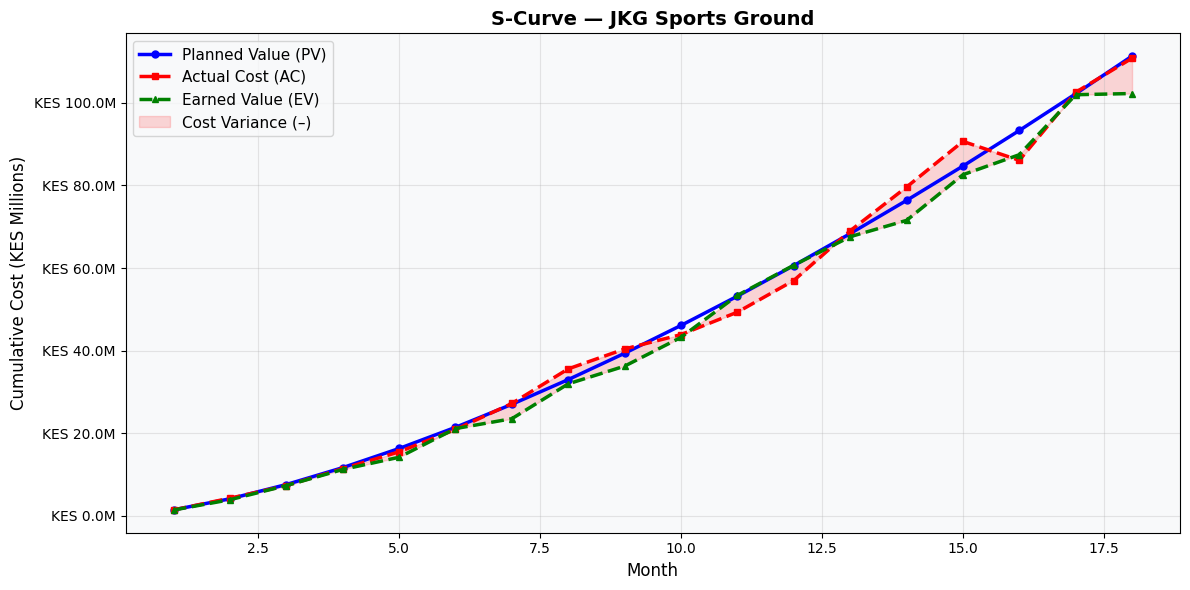

✓ S-curve saved → s_curve.png


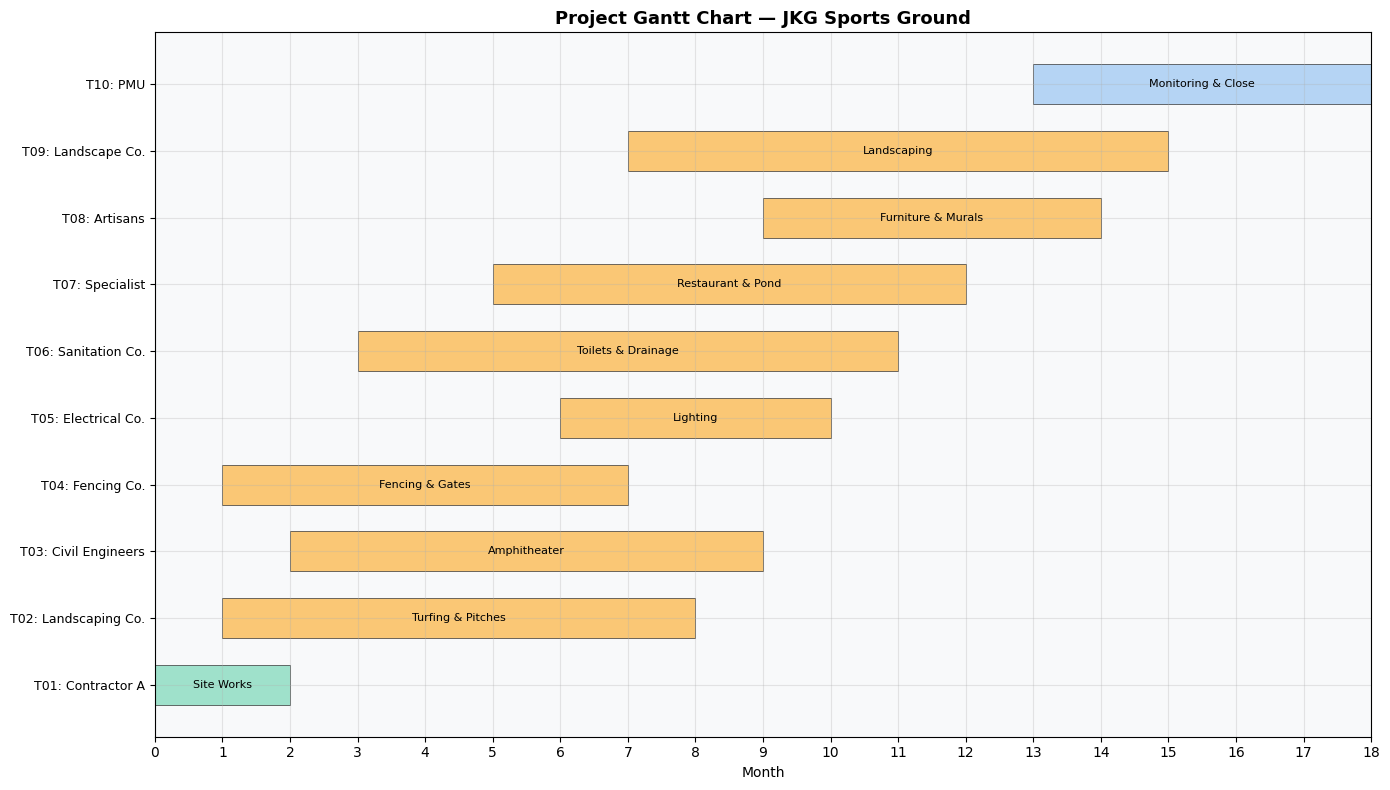

✓ Gantt chart saved → gantt_chart.png

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STEP 4 — Computer Vision Floor Plan Generation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


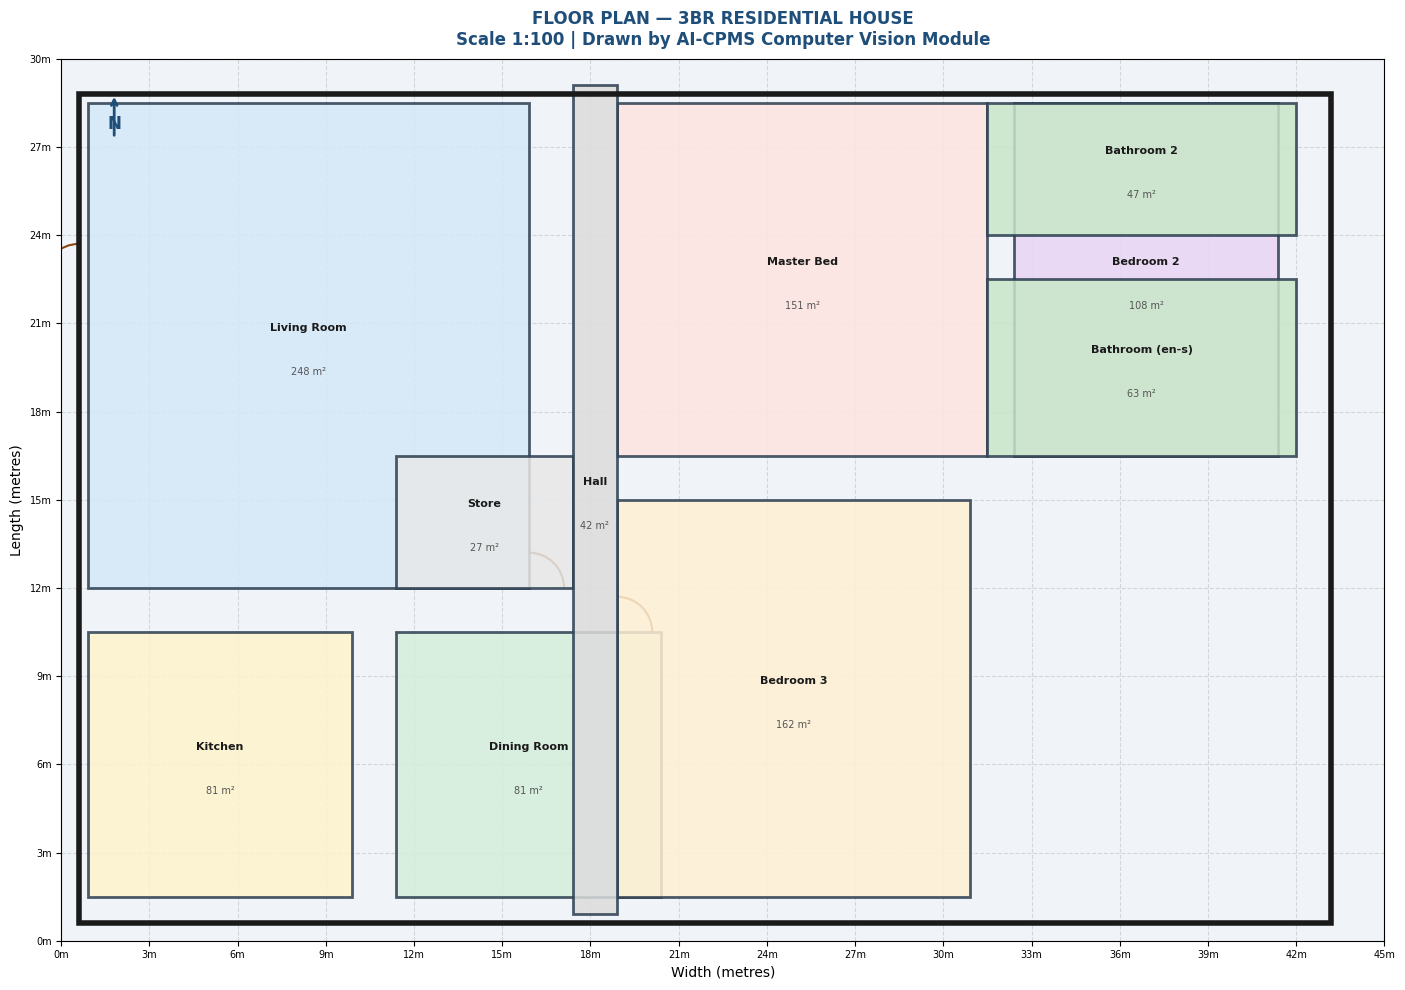

✓ Blueprint saved → house_blueprint.png

─── AUTOMATED QUANTITY TAKE-OFF ─────────────────────────────
  Room                          W      H   Area m²
  --------------------------------------------------
  Living Room                 5.0    5.5     247.5
  Kitchen                     3.0    3.0      81.0
  Dining Room                 3.0    3.0      81.0
  Master Bed                  4.2    4.0     151.2
  Bedroom 2                   3.0    4.0     108.0
  Bedroom 3                   4.0    4.5     162.0
  Bathroom (en-s)             3.5    2.0      63.0
  Bathroom 2                  3.5    1.5      47.2
  Store                       2.0    1.5      27.0
  Corridor                    0.5    9.4      42.3
  TOTAL FLOOR AREA                          1010.2 m²

  Estimated Perimeter:          127.1 m
  Cost Rate (residential):         KES 45,000/m²
  Base Construction Cost:       KES     45,461,250
  + 10% Contingency:            KES     50,007,375
  + 14% VAT:                    KES  

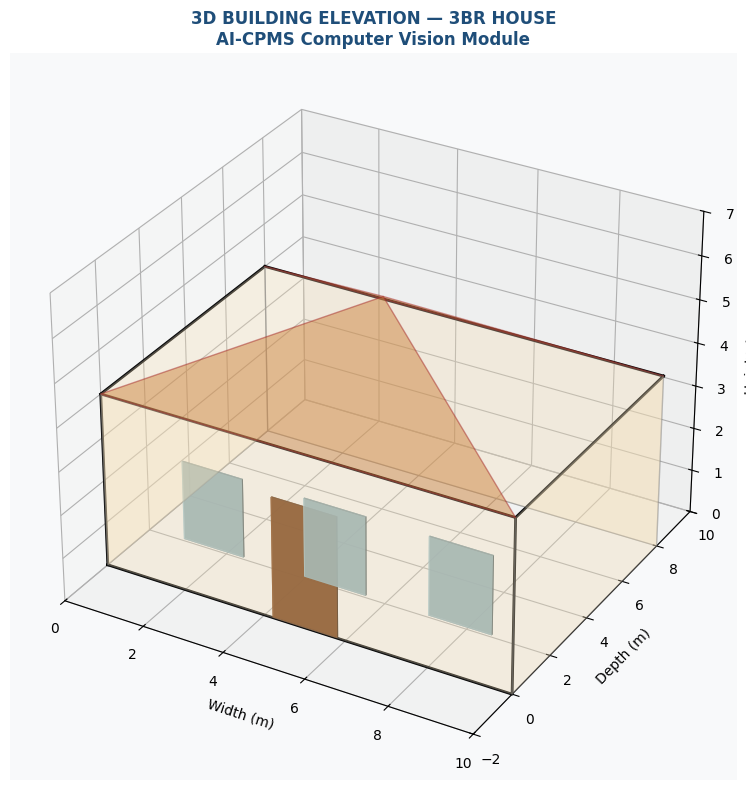

✓ 3D elevation saved → elevation_3d.png


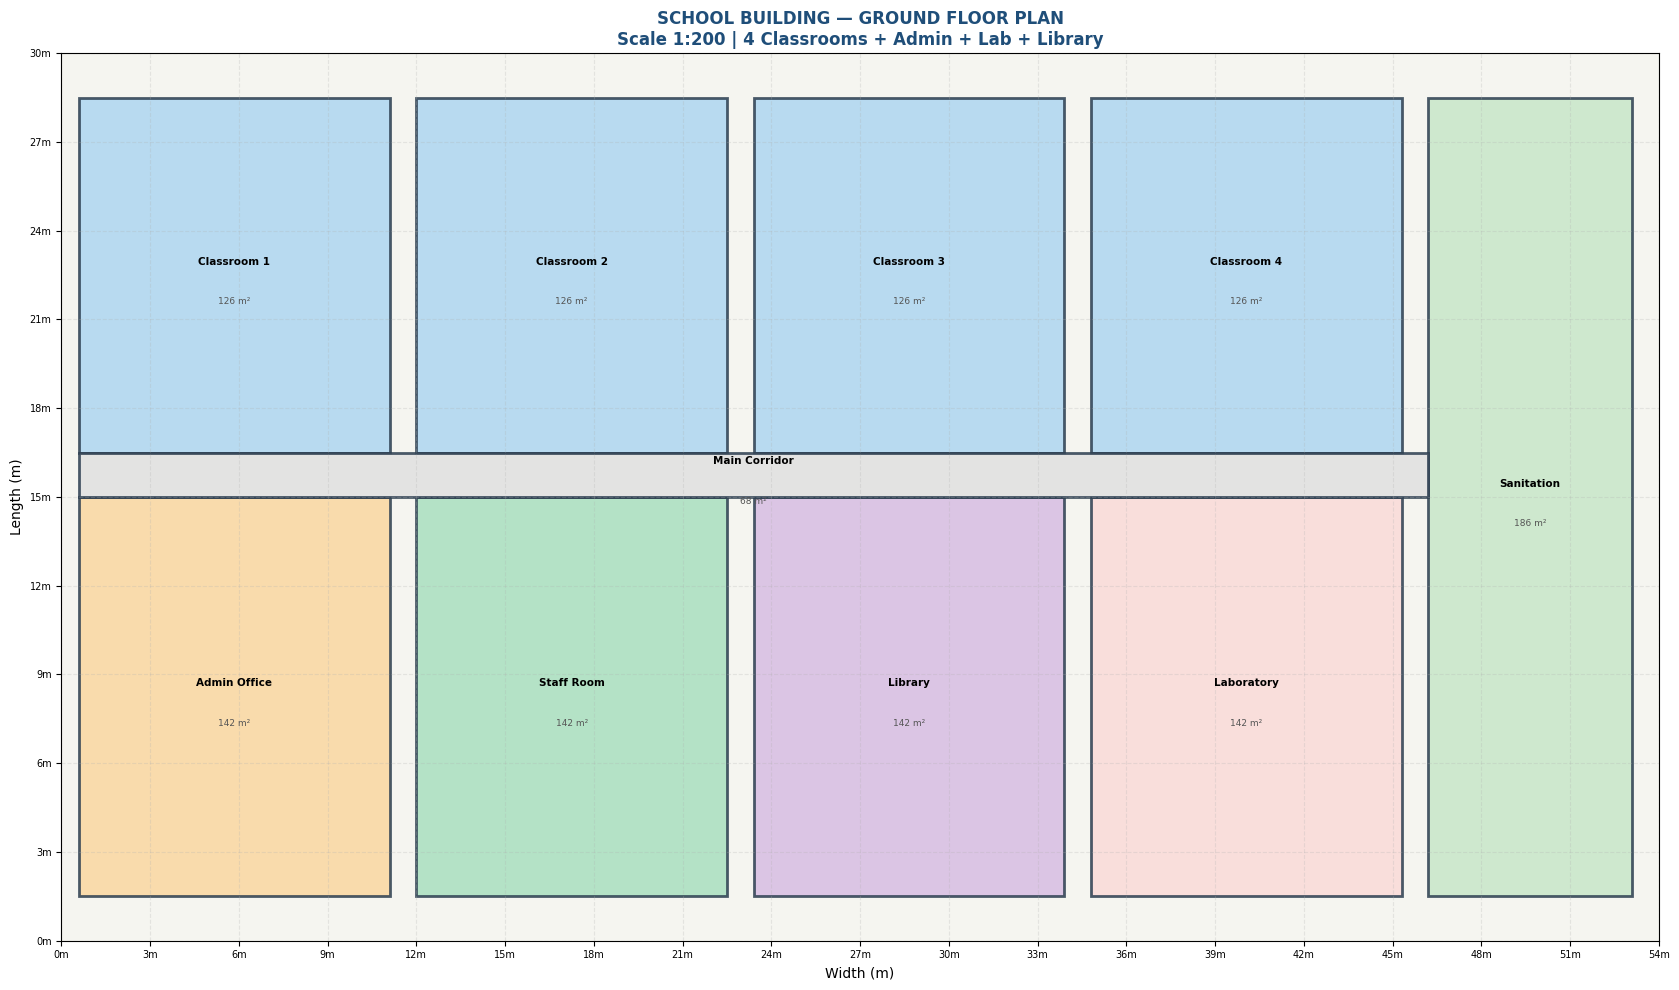

✓ School plan saved → school_plan.png

─── AUTOMATED QUANTITY TAKE-OFF ─────────────────────────────
  Room                          W      H   Area m²
  --------------------------------------------------
  Classroom 1                 3.5    4.0     126.0
  Classroom 2                 3.5    4.0     126.0
  Classroom 3                 3.5    4.0     126.0
  Classroom 4                 3.5    4.0     126.0
  Admin Office                3.5    4.5     141.8
  Staff Room                  3.5    4.5     141.8
  Library                     3.5    4.5     141.8
  Laboratory                  3.5    4.5     141.8
  Sanitation                  2.3    9.0     186.3
  Main Corridor              15.2    0.5      68.4
  TOTAL FLOOR AREA                          1325.7 m²

  Estimated Perimeter:          145.6 m
  Cost Rate (school):         KES 38,000/m²
  Base Construction Cost:       KES     50,376,600
  + 10% Contingency:            KES     55,414,260
  + 14% VAT:                    KES     63,1

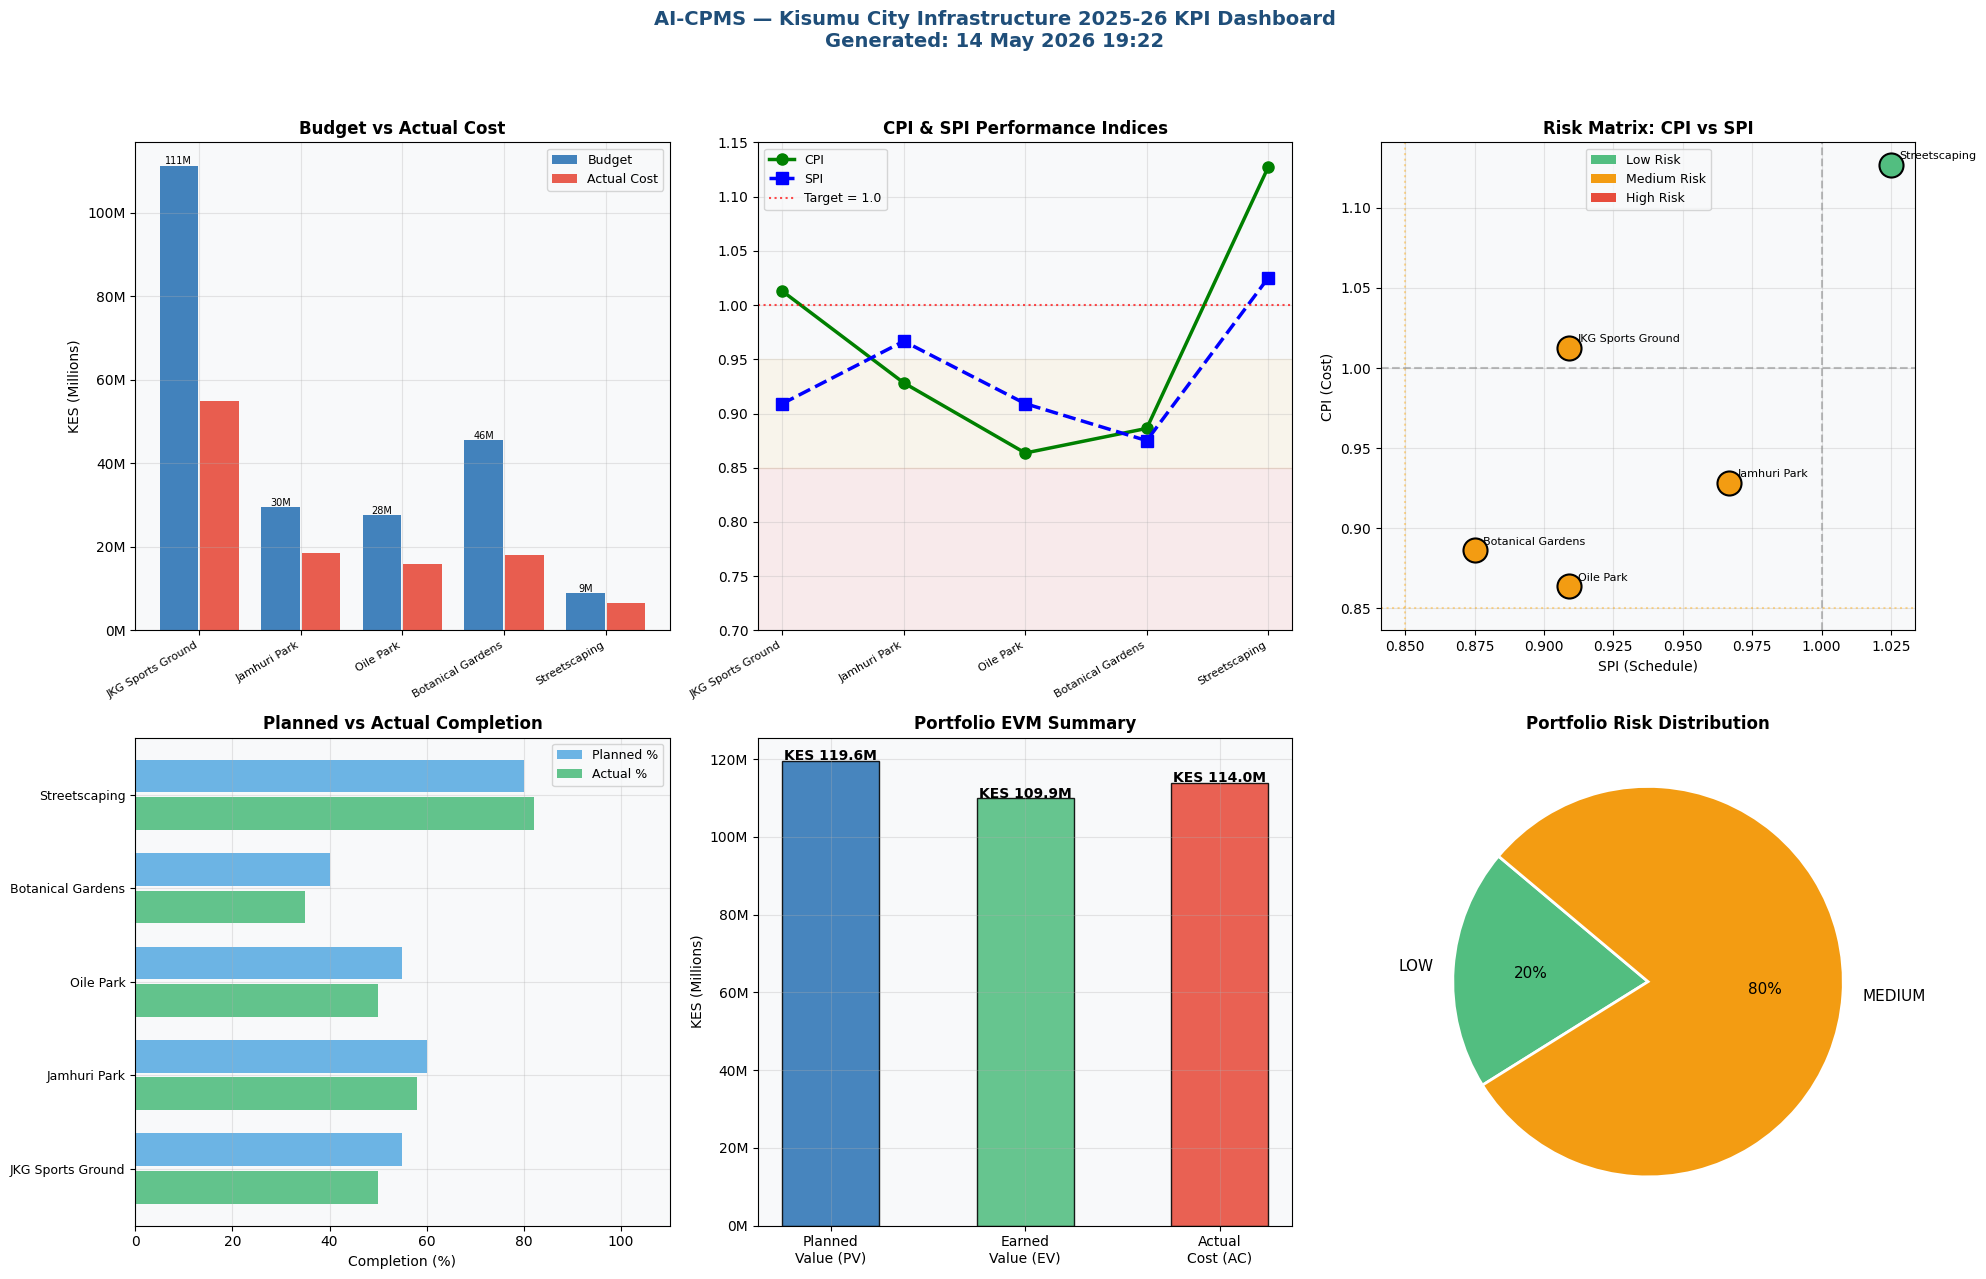

✓ Dashboard saved → kpi_dashboard.png

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STEP 6 — Generating Downloadable Word Report
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Report saved → AI_CPMS_JKG_Full_Report.docx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download triggered in Colab

╔══════════════════════════════════════════════════════════╗
║                  PIPELINE COMPLETE ✓                    ║
╠══════════════════════════════════════════════════════════╣
║  BOQ Grand Total:  KES     116,030,902.02        ║
║  EVM CPI:          0.9966                             ║
║  EVM SPI:          0.7020                             ║
║  Outputs: proposals, BOQs, S-curve, Gantt, Dashboard   ║
║  Report:  AI_CPMS_JKG_Full_Report.docx                 ║
╚══════════════════════════════════════════════════════════╝


In [ ]:
# ============================================================
# MASTER PIPELINE RUNNER — Execute Full AI-CPMS
# ============================================================

print("╔══════════════════════════════════════════════════════════╗")
print("║    AI-CPMS: AI-Driven Construction Project Mgmt System  ║")
print("║    Author: Henry Kissinger Onyango | BSBI/UCA | 2026    ║")
print("╚══════════════════════════════════════════════════════════╝")
print()

# ── STEP 1: Proposal ──────────────────────────────────────
print("━"*60)
print("STEP 1 — AI Business Proposal Generator")
print("━"*60)
gen = AIProposalGenerator()
stadium_proposal = gen.generate_proposal({
    'name':     'Jomo Kenyatta Sports Ground Rehabilitation',
    'type':     'stadium',
    'location': 'Kisumu City Centre, Kenya',
    'client':   'County Government of Kisumu / KUSP',
    'area':     23200,
    'budget':   111_328_291.44,
})
gen.display(stadium_proposal)

# ── STEP 2: BOQ ───────────────────────────────────────────
print("\n" + "━"*60)
print("STEP 2 — Automated BOQ Engine")
print("━"*60)
boq = BOQEngine()
stadium_items = [
    {'description':'Site Clearance (23,200 SM)',   'unit':'SM',   'quantity':23200, 'rate':120},
    {'description':'Anti-termite Fumigation',       'unit':'SM',   'quantity':17400, 'rate':18},
    {'description':'Good Earth & Levelling',        'unit':'SM',   'quantity':5661,  'rate':850},
    {'description':'Farm Yard Manure Application',  'unit':'SM',   'quantity':4640,  'rate':1150},
    {'description':'Paspalum Turfing (pitch)',       'unit':'SM',   'quantity':15849, 'rate':320},
    {'description':'Amphitheater Construction',     'unit':'SM',   'quantity':1359,  'rate':1600},
    {'description':'Football Pitch Furniture',      'unit':'ITEM', 'quantity':1,     'rate':1600000},
    {'description':'Hockey Pitch Turfing',          'unit':'SM',   'quantity':3888,  'rate':1000},
    {'description':'Basketball Rehabilitation',     'unit':'ITEM', 'quantity':1,     'rate':420000},
    {'description':'Children Play Area',            'unit':'ITEM', 'quantity':1,     'rate':1977500},
    {'description':'Pond Rehabilitation',           'unit':'ITEM', 'quantity':1,     'rate':2400000},
    {'description':'Restaurant (pond-side)',        'unit':'ITEM', 'quantity':1,     'rate':4500000},
    {'description':'Public Toilets (repair + new)', 'unit':'ITEM', 'quantity':1,     'rate':11800000},
    {'description':'ODM Mikayi Platform',           'unit':'SM',   'quantity':2500,  'rate':1800},
    {'description':'Perimeter Masonry Fence',       'unit':'LM',   'quantity':1300,  'rate':6400},
    {'description':'Creeper Plants on Wall',        'unit':'NO',   'quantity':2000,  'rate':350},
    {'description':'Solar Perimeter Lighting',      'unit':'NO',   'quantity':150,   'rate':32000},
    {'description':'Security Gates (main)',         'unit':'NO',   'quantity':4,     'rate':1600000},
    {'description':'Security Gates (secondary)',    'unit':'NO',   'quantity':3,     'rate':800000},
    {'description':'Park Benches',                  'unit':'NO',   'quantity':80,    'rate':12000},
    {'description':'Dustbins (specialist)',         'unit':'NO',   'quantity':100,   'rate':6000},
    {'description':'Landscape Trees',               'unit':'NO',   'quantity':200,   'rate':1500},
    {'description':'Shrubs & Groundcovers',         'unit':'NO',   'quantity':4800,  'rate':390},
    {'description':'Statues/Murals (prominent Luo)','unit':'ITEM', 'quantity':20,    'rate':140000},
    {'description':'Irrigation System (repair)',    'unit':'ITEM', 'quantity':1,     'rate':1800000},
    {'description':'Landscape Maintenance (12 mo)','unit':'MONTHS','quantity':12,   'rate':500000},
    {'description':'Contingency (provisional)',     'unit':'SUM',  'quantity':1,     'rate':4000000},
]
df_stadium, summary_stadium, total_stadium = boq.generate_boq(
    'JKG Jomo Kenyatta Sports Ground — Kisumu', stadium_items)
print(f"\nExpected Grand Total: KES 111,328,291.44")
boq.plot_cost_breakdown(df_stadium.head(12), 'JKG Stadium — Top 12 Items')

# ── STEP 3: Budget & EVM ──────────────────────────────────
print("\n" + "━"*60)
print("STEP 3 — Budget Planning & Earned Value Management")
print("━"*60)
planner_jkg = BudgetPlanner('JKG Sports Ground', 111_328_291.44, 18)
planner_jkg.add_task('T01','Site Works',         5,  1,2, 'Contractor A')
planner_jkg.add_task('T02','Turfing & Pitches',  20, 2,8, 'Landscaping Co.', ['T01'])
planner_jkg.add_task('T03','Amphitheater',        8,  3,9, 'Civil Engineers', ['T01'])
planner_jkg.add_task('T04','Fencing & Gates',    14,  2,7, 'Fencing Co.')
planner_jkg.add_task('T05','Lighting',            5,  7,10,'Electrical Co.',  ['T04'])
planner_jkg.add_task('T06','Toilets & Drainage',  10, 4,11,'Sanitation Co.')
planner_jkg.add_task('T07','Restaurant & Pond',   8,  6,12,'Specialist')
planner_jkg.add_task('T08','Furniture & Murals',  5, 10,14,'Artisans')
planner_jkg.add_task('T09','Landscaping',          7,  8,15,'Landscape Co.')
planner_jkg.add_task('T10','Monitoring & Close',   5, 14,18,'PMU')

# Simulate status at month 10
for tid, pct, cost in [
    ('T01',100, 5_600_000), ('T02',75, 16_700_000), ('T03',60, 5_340_000),
    ('T04',90,  14_200_000), ('T05',40, 2_230_000), ('T06',55, 6_100_000),
    ('T07',30,  2_670_000), ('T08',10, 560_000), ('T09',20, 1_560_000),
    ('T10',0,   0),
]:
    planner_jkg.update_task(tid, pct, cost)

resources_jkg = {
    'Senior Project Manager': {'count':1, 'rate_per_day':15000, 'working_days':360},
    'Civil Engineers (x2)':   {'count':2, 'rate_per_day':9000,  'working_days':360},
    'Quantity Surveyor':       {'count':1, 'rate_per_day':8000,  'working_days':200},
    'Site Supervisor':         {'count':3, 'rate_per_day':5000,  'working_days':360},
    'Artisans & Fundis':       {'count':20,'rate_per_day':2500,  'working_days':360},
    'General Labourers':       {'count':40,'rate_per_day':800,   'working_days':360},
    'Equipment Operators':     {'count':4, 'rate_per_day':5500,  'working_days':200},
    'Landscape Specialist':    {'count':2, 'rate_per_day':7000,  'working_days':150},
}
planner_jkg.allocate_resources(resources_jkg)
evm_jkg = planner_jkg.compute_evm(10, 54_960_000)
planner_jkg.plot_s_curve()
planner_jkg.plot_gantt()

# ── STEP 4: Computer Vision ───────────────────────────────
print("\n" + "━"*60)
print("STEP 4 — Computer Vision Floor Plan Generation")
print("━"*60)
cv = BuildingDesignCV()
house_rooms = cv.generate_house_blueprint('3BR','house_blueprint.png')
cv.analyze_floor_plan(house_rooms, 'residential')
cv.generate_3d_elevation('elevation_3d.png')
school_rooms = cv.generate_school_plan('school_plan.png')
cv.analyze_floor_plan(school_rooms, 'school')

# ── STEP 5: Portfolio Dashboard ───────────────────────────
print("\n" + "━"*60)
print("STEP 5 — Multi-Project KPI Dashboard")
print("━"*60)
dash = ProjectDashboard('Kisumu City Infrastructure 2025-26')
dash.add_project('JKG Sports Ground',  111_328_291, 55, 50, 54_960_000, 10)
dash.add_project('Jamhuri Park',        29_607_492, 60, 58, 18_500_000,  5)
dash.add_project('Oile Park',           27_634_987, 55, 50, 16_000_000, 20)
dash.add_project('Botanical Gardens',   45_579_640, 40, 35, 18_000_000, 30)
dash.add_project('Streetscaping',        8_934_123, 80, 82,  6_500_000,  0)
dash.summary_table()
dash.generate_dashboard('kpi_dashboard.png')

# ── STEP 6: Word Report Export ────────────────────────────
print("\n" + "━"*60)
print("STEP 6 — Generating Downloadable Word Report")
print("━"*60)

def generate_full_report(proposal, boq_df, evm_data, filename='AI_CPMS_Report.docx'):
    """Generate a full project Word report."""
    doc = Document()

    # Cover
    t = doc.add_heading('AI-CPMS PROJECT REPORT', 0)
    t.alignment = WD_ALIGN_PARAGRAPH.CENTER
    doc.add_paragraph(f"Project: {proposal['title']}")
    doc.add_paragraph(f"Client:  {proposal['client']}")
    doc.add_paragraph(f"Date:    {proposal['date']}")
    doc.add_paragraph(f"Ref:     {proposal['ref']}")
    doc.add_page_break()

    # Proposal
    doc.add_heading('1. Business Proposal', 1)
    doc.add_paragraph(proposal['introduction'])
    doc.add_heading('Scope of Work', 2)
    for item in proposal['scope_of_work']:
        doc.add_paragraph(item, style='List Bullet')
    doc.add_paragraph(
        f"Estimated Budget: KES {proposal['estimated_budget']:,.2f}\n"
        f"Timeline: {proposal['timeline_months']} months\n"
        f"Payment Terms: {proposal['payment_terms']}"
    )
    doc.add_page_break()

    # BOQ
    doc.add_heading('2. Bill of Quantities (Summary)', 1)
    cols = list(boq_df.columns)
    tbl  = doc.add_table(rows=1, cols=len(cols))
    tbl.style = 'Table Grid'
    for i, col in enumerate(cols):
        tbl.rows[0].cells[i].text = col
    for _, row in boq_df.head(15).iterrows():
        cells = tbl.add_row().cells
        for i, v in enumerate(row):
            cells[i].text = str(v)
    doc.add_page_break()

    # EVM
    doc.add_heading('3. Earned Value Management Report', 1)
    if evm_data:
        evm_tbl = doc.add_table(rows=1, cols=2)
        evm_tbl.style = 'Table Grid'
        evm_tbl.rows[0].cells[0].text = 'Metric'
        evm_tbl.rows[0].cells[1].text = 'Value'
        kpi_labels = {
            'PV':'Planned Value (KES)', 'EV':'Earned Value (KES)',
            'AC':'Actual Cost (KES)', 'CV':'Cost Variance (KES)',
            'SV':'Schedule Variance (KES)', 'CPI':'Cost Performance Index',
            'SPI':'Schedule Performance Index', 'EAC':'Estimate at Completion (KES)',
        }
        for key, label in kpi_labels.items():
            if key in evm_data:
                row = evm_tbl.add_row().cells
                row[0].text = label
                v = evm_data[key]
                row[1].text = f'KES {v:,.2f}' if key in ('PV','EV','AC','CV','SV','EAC') else f'{v:.4f}'

    doc.save(filename)
    print(f"✓ Report saved → {filename}")
    try:
        from google.colab import files
        files.download(filename)
        print("✓ Download triggered in Colab")
    except Exception:
        print(f"  (Open {filename} from the Colab file browser)")
    return filename

report_file = generate_full_report(
    stadium_proposal,
    df_stadium,
    evm_jkg,
    'AI_CPMS_JKG_Full_Report.docx'
)

print()
print("╔══════════════════════════════════════════════════════════╗")
print("║                  PIPELINE COMPLETE ✓                    ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  BOQ Grand Total:  KES {total_stadium:>18,.2f}        ║")
print(f"║  EVM CPI:          {evm_jkg['CPI']:.4f}                             ║")
print(f"║  EVM SPI:          {evm_jkg['SPI']:.4f}                             ║")
print(f"║  Outputs: proposals, BOQs, S-curve, Gantt, Dashboard   ║")
print(f"║  Report:  AI_CPMS_JKG_Full_Report.docx                 ║")
print("╚══════════════════════════════════════════════════════════╝")